In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/yield_prediction_dataset.csv')

Mounted at /content/drive


In [4]:
import pandas as pd

# Load the dataset
# df = pd.read_csv('yield_prediction_dataset.csv') # This line is removed as df is already loaded from drive

# 1. Check for duplicates
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Remove duplicates if any were found
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

# 2. Cleanup: Dropping the empty columns identified during inspection
cols_to_drop = [col for col in ['Unnamed: 13', 'Unnamed: 14'] if col in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

# 3. Encoding 'crop_type' using dummy variables
# This creates a new binary column for each unique crop type
df_encoded = pd.get_dummies(df, columns=['crop_type'], prefix='crop')

# Display the first few rows of the updated dataframe
print("\n--- Encoded Dataframe Head ---")
print(df_encoded.head())

# Save the processed data for next steps
df_encoded.to_csv('yield_prediction_processed.csv', index=False)

Number of duplicate rows: 0

--- Encoded Dataframe Head ---
  field_id date_of_image   latitude  longitude      NDVI     GNDVI      NDWI  \
0  Field_1      1/1/2023  22.625231  88.497925  0.060190  0.084801 -0.084801   
1  Field_1    16-01-2023  22.625231  88.497925  0.213957  0.222009 -0.222009   
2  Field_1    31-01-2023  22.625231  88.497925  0.403306  0.431204 -0.431204   
3  Field_1    15-02-2023  22.625231  88.497925  0.418187  0.444132 -0.444132   
4  Field_1      3/2/2023  22.625231  88.497925  0.375138  0.387985 -0.387985   

       SAVI  soil_moisture  temperature  ...  crop_Saffron  crop_Sesame  \
0  0.090280      46.119353     9.884229  ...         False        False   
1  0.320896      37.542525    13.967073  ...         False        False   
2  0.604837      24.926279    13.590147  ...         False        False   
3  0.627144      24.114157    12.343355  ...         False        False   
4  0.562591      27.420927    11.007707  ...         False        False   

   crop_

In [5]:
from sklearn.model_selection import train_test_split

# 1. Load the processed dataset
df = pd.read_csv('yield_prediction_processed.csv')

# 2. Reconstruct 'crop_type' column from one-hot encoded features for stratification
crop_cols = [col for col in df.columns if col.startswith('crop_')]
# Use idxmax to find which crop_ column is True for each row, then remove the 'crop_' prefix.
df['crop_type'] = df[crop_cols].idxmax(axis=1).str.replace('crop_', '')

# 3. Define Features (X) and Target (y)
# We drop 'yield' (the target) and the original identifier columns.
# Note: 'crop_type' will be used for stratification and then dropped from X_train/X_test as it's represented by dummy variables.
X = df.drop(columns=['yield'])
y = df['yield']

# 4. Perform the Stratified Split
# test_size=0.2 creates an 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=df['crop_type'], # Stratify by the reconstructed 'crop_type'
    random_state=42
)

# 5. Drop specified columns from X_train and X_test right after splitting
# This includes original identifiers and the temporary 'crop_type' column used for stratification.
columns_to_drop = ['latitude', 'longitude', 'field_id', 'date_of_image', 'crop_type']
X_train = X_train.drop(columns=[col for col in columns_to_drop if col in X_train.columns])
X_test = X_test.drop(columns=[col for col in columns_to_drop if col in X_test.columns])

# 6. Verify the split sizes
print(f"Total samples: {len(df)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")


Total samples: 1625
Training samples: 1300
Testing samples: 325


In [ ]:
# Check for missing values in training and testing sets
print("Missing values in X_train:\n", X_train.isnull().sum()[X_train.isnull().sum() > 0])
print("\nMissing values in X_test:\n", X_test.isnull().sum()[X_test.isnull().sum() > 0])
print("\nMissing values in y_train:\n", y_train.isnull().sum())
print("\nMissing values in y_test:\n", y_test.isnull().sum())

Missing values in X_train:
 Series([], dtype: int64)

Missing values in X_test:
 Series([], dtype: int64)

Missing values in y_train:
 0

Missing values in y_test:
 0


Detected 65 outliers out of 1300 records.


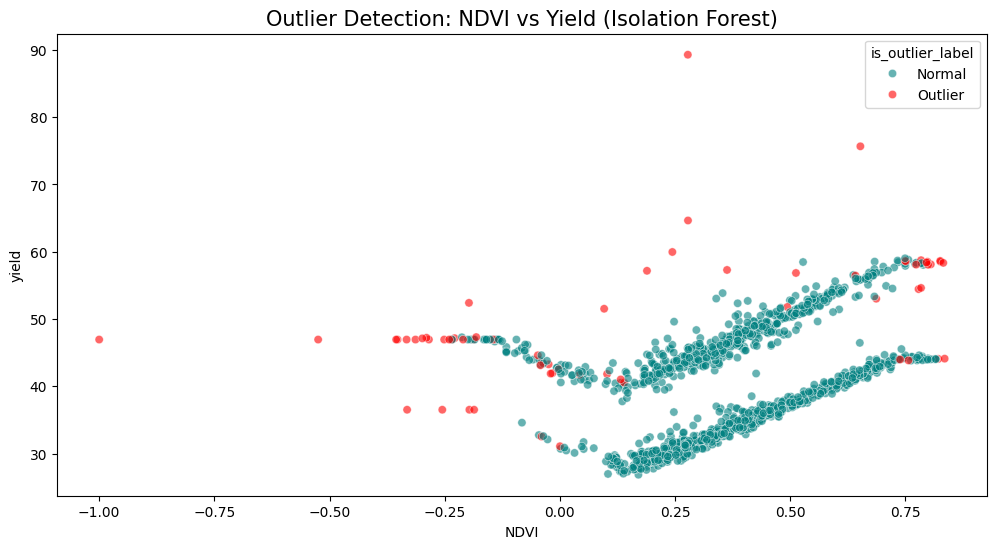

In [ ]:
from sklearn.ensemble import IsolationForest
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select the numeric features you want to check for anomalies
# We exclude the one-hot encoded crop columns to focus on sensor/environmental patterns
features_to_check = ['NDVI', 'rainfall', 'soil_moisture', 'temperature']

# 2. Initialize and Fit Isolation Forest
# contamination=0.05 means we expect roughly 5% of the data to be outliers
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
outlier_preds = iso_forest.fit_predict(X_train[features_to_check])

# 3. Add results back to a copy of your training dataframe
# Isolation Forest returns 1 for inliers and -1 for outliers
train_analysis = X_train.copy()
train_analysis['yield'] = y_train
train_analysis['is_outlier'] = outlier_preds
train_analysis['is_outlier_label'] = train_analysis['is_outlier'].map({1: 'Normal', -1: 'Outlier'})

# 4. Summary of findings
num_outliers = (train_analysis['is_outlier'] == -1).sum()
print(f"Detected {num_outliers} outliers out of {len(train_analysis)} records.")

# 5. Visualize Outliers (NDVI vs Yield)
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=train_analysis,
    x='NDVI',
    y='yield',
    hue='is_outlier_label',
    palette={'Normal': 'teal', 'Outlier': 'red'},
    alpha=0.6
)
plt.title('Outlier Detection: NDVI vs Yield (Isolation Forest)', fontsize=15)
plt.show()

In [ ]:
outliers_df = train_analysis[train_analysis['is_outlier'] == -1]
print("--- Identified Outlier Records ---")
display(outliers_df)

--- Identified Outlier Records ---


,NDVI,GNDVI,soil_moisture,temperature,rainfall,crop_Barley,crop_Black Pepper,crop_Cardamom,crop_Cashew Nut,crop_Coconut,...,crop_Soybean,crop_Sugarcane,crop_Sunflower,crop_Tea,crop_Tobacco,crop_Turmeric,crop_Wheat,yield,is_outlier,is_outlier_label
1114,-0.332735,-0.761004,93.322715,34.884584,6.701160,False,False,False,True,False,...,False,False,False,False,False,False,False,46.947117,-1,Outlier
1567,-0.235095,-0.526132,80.331978,29.438947,6.701160,False,False,False,False,True,...,False,False,False,False,False,False,False,46.947117,-1,Outlier
1552,-0.188445,-0.578668,82.538266,39.288937,6.701160,False,False,False,False,True,...,False,False,False,False,False,False,False,46.947117,-1,Outlier
1048,0.686578,0.638852,11.429849,39.874702,1.313326,False,True,False,False,False,...,False,False,False,False,False,False,False,53.018945,-1,Outlier
1599,0.826227,0.735068,5.090446,22.904506,17.124036,False,False,False,False,False,...,False,False,False,False,False,False,False,58.527406,-1,Outlier
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,0.783839,0.685683,8.045163,32.736508,5.322920,False,False,False,False,False,...,False,False,False,False,False,False,False,54.625579,-1,Outlier
1378,0.795712,0.710269,6.668448,27.385592,16.893545,False,False,False,False,False,...,False,False,False,False,False,False,False,58.402214,-1,Outlier
1286,0.131988,0.127291,43.216335,-3.156287,11.936587,False,False,False,False,False,...,False,False,False,False,False,False,False,41.021348,-1,Outlier
75,0.756505,0.713039,6.927401,0.336860,9.317462,False,False,False,False,False,...,False,False,False,False,False,False,True,43.848608,-1,Outlier


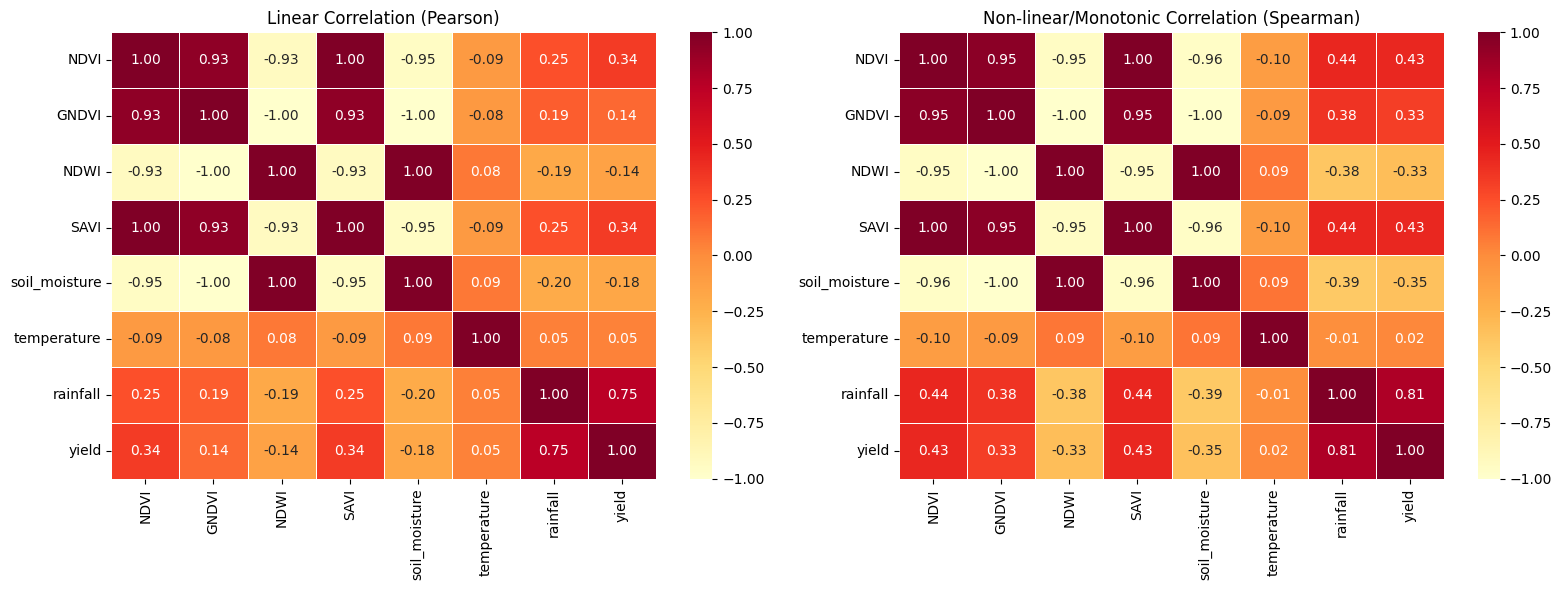

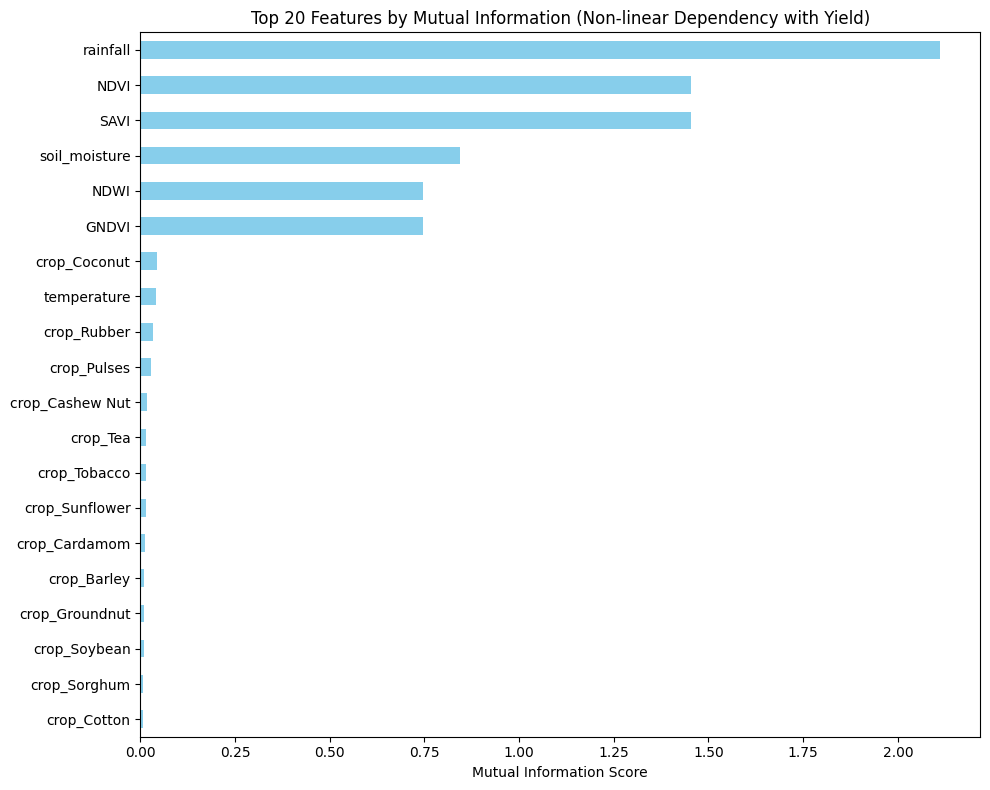

Pearson Correlation with Yield:
 yield            1.000000
rainfall         0.752586
SAVI             0.342347
NDVI             0.342240
GNDVI            0.144725
temperature      0.045153
NDWI            -0.144725
soil_moisture   -0.178652
Name: yield, dtype: float64

Spearman Correlation with Yield:
 yield            1.000000
rainfall         0.809618
SAVI             0.430463
NDVI             0.430449
GNDVI            0.327477
temperature      0.021474
NDWI            -0.327477
soil_moisture   -0.348567
Name: yield, dtype: float64


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
import numpy as np

# 1. Load the split training data
# X_train = pd.read_csv('X_train.csv') # X_train is already in memory
# y_train = pd.read_csv('y_train.csv') # y_train is already in memory

# Combine them for correlation analysis
train_data = pd.concat([X_train, y_train], axis=1)

# List of numerical features to keep the heatmap clean
# 'latitude' and 'longitude' were dropped in the previous step
# Removed 'NDWI' and 'SAVI' as they are not in the dataset.
numerical_cols = ['NDVI', 'GNDVI', 'NDWI', 'SAVI',
                  'soil_moisture', 'temperature', 'rainfall', 'yield']

# 2. Calculate Linear (Pearson) and Non-linear/Monotonic (Spearman) Correlations
pearson_corr = train_data[numerical_cols].corr(method='pearson')
spearman_corr = train_data[numerical_cols].corr(method='spearman')

# 3. Visualization: Correlation Heatmaps
plt.figure(figsize=(16, 6))

# Subplot 1: Pearson
plt.subplot(1, 2, 1)
sns.heatmap(pearson_corr, annot=True, cmap='YlOrRd', fmt=".2f", linewidths=0.5)
plt.title('Linear Correlation (Pearson)')

# Subplot 2: Spearman
plt.subplot(1, 2, 2)
sns.heatmap(spearman_corr, annot=True, cmap='YlOrRd', fmt=".2f", linewidths=0.5)
plt.title('Non-linear/Monotonic Correlation (Spearman)')

plt.tight_layout()
plt.savefig('correlation_heatmaps.png')
plt.show()

# 4. Calculate Mutual Information (Non-linear Dependency)
# Drop non-numeric ID columns that aren't useful for math calculations
# These columns have already been dropped from X_train in the train_test_split step
X_mi = X_train

# Compute MI scores
mi_scores = mutual_info_regression(X_mi, y_train.values.ravel(), random_state=42)
mi_series = pd.Series(mi_scores, name="MI Scores", index=X_mi.columns).sort_values(ascending=False)

# 5. Visualization: Mutual Information Plot
plt.figure(figsize=(10, 8))
mi_series.head(20).plot(kind='barh', color='skyblue')
plt.title('Top 20 Features by Mutual Information (Non-linear Dependency with Yield)')
plt.xlabel('Mutual Information Score')
plt.gca().invert_yaxis() # Highest scores at the top
plt.tight_layout()
plt.savefig('mutual_info_plot.png')
plt.show()

# Print specific correlations with the target variable 'yield'
print("Pearson Correlation with Yield:\n", pearson_corr['yield'].sort_values(ascending=False))
print("\nSpearman Correlation with Yield:\n", spearman_corr['yield'].sort_values(ascending=False))

In [7]:
import pandas as pd

# Load the final training and testing data
X_train_final = pd.read_csv('X_train_final.csv')
X_test_final = pd.read_csv('X_test_final.csv')

# Columns to drop
cols_to_remove = ['GNDVI', 'NDWI', 'SAVI']

# Drop columns from X_train_final and X_test_final
X_train_final_cleaned = X_train_final.drop(columns=cols_to_remove, errors='ignore')
X_test_final_cleaned = X_test_final.drop(columns=cols_to_remove, errors='ignore')

# Save the cleaned data to new CSV files
X_train_final_cleaned.to_csv('X_train_final_cleaned.csv', index=False)
X_test_final_cleaned.to_csv('X_test_final_cleaned.csv', index=False)

print(f"Removed {cols_to_remove} from X_train_final and X_test_final.")
print("Saved new data to 'X_train_final_cleaned.csv' and 'X_test_final_cleaned.csv'.")

# Display the head of the cleaned training data to confirm
print("\nHead of X_train_final_cleaned:")
display(X_train_final_cleaned.head())

Removed ['GNDVI', 'NDWI', 'SAVI'] from X_train_final and X_test_final.
Saved new data to 'X_train_final_cleaned.csv' and 'X_test_final_cleaned.csv'.

Head of X_train_final_cleaned:


,NDVI,soil_moisture,rainfall,crop_Barley,crop_Black Pepper,crop_Cardamom,crop_Cashew Nut,crop_Coconut,crop_Coffee,crop_Corn,...,crop_Saffron,crop_Sesame,crop_Sorghum,crop_Soybean,crop_Sugarcane,crop_Sunflower,crop_Tea,crop_Tobacco,crop_Turmeric,crop_Wheat
0,0.246703,28.177414,12.408858,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,0.458494,19.320183,7.084997,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0.173375,38.267616,5.274941,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0.310681,27.406340,6.067075,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,0.311592,25.690498,5.996517,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


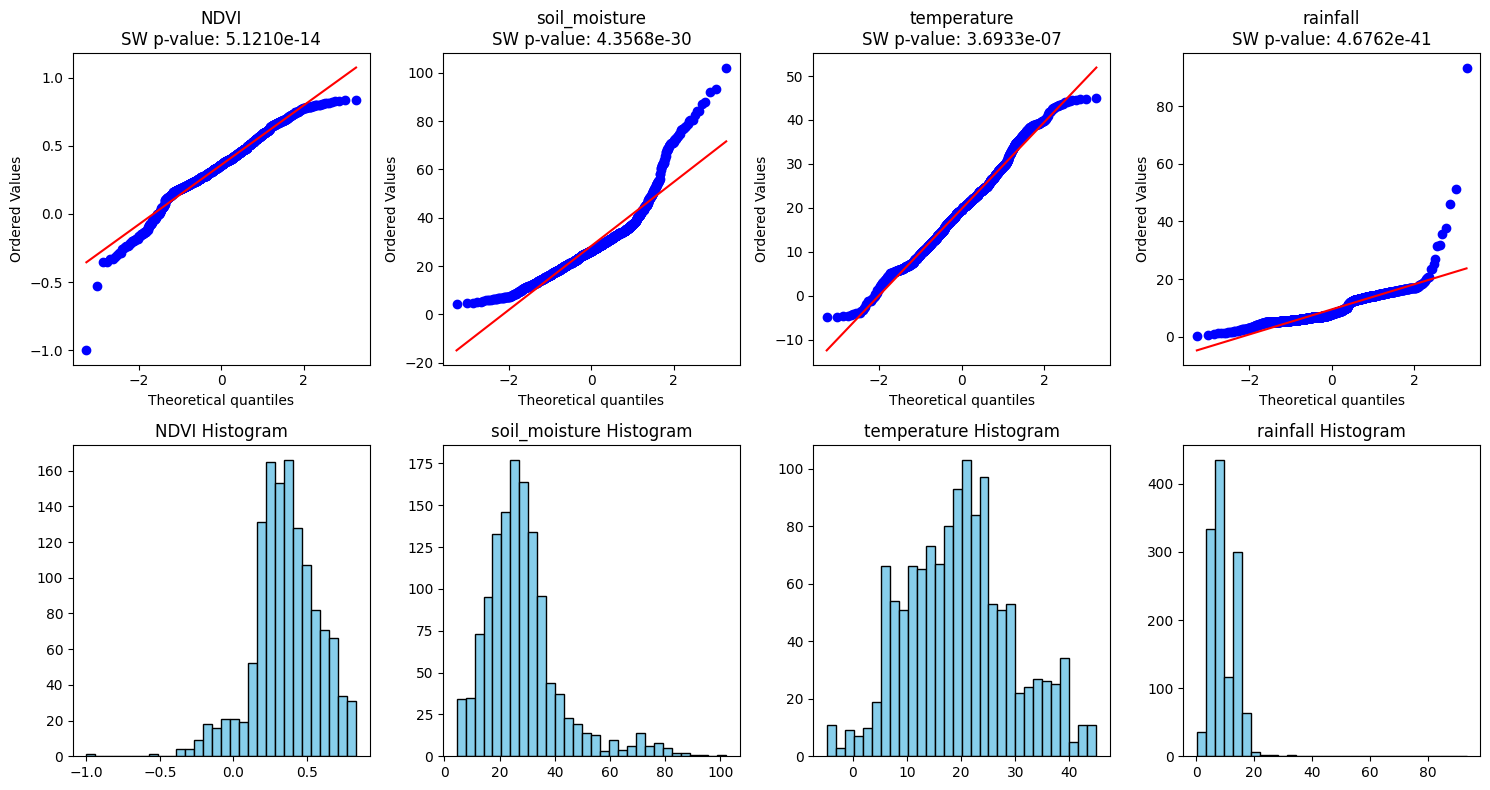

----------------------------------------
NORMALITY VERDICT
----------------------------------------
NDVI           : p=5.1210e-14 -> Verdict: Non-Parametric (Not Normal)
soil_moisture  : p=4.3568e-30 -> Verdict: Non-Parametric (Not Normal)
temperature    : p=3.6933e-07 -> Verdict: Non-Parametric (Not Normal)
rainfall       : p=4.6762e-41 -> Verdict: Non-Parametric (Not Normal)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# Assuming X_train is your current dataframe containing the processed features
features = ['NDVI','soil_moisture', 'temperature', 'rainfall']

# Changed to a 2x4 grid which perfectly fits 8 plots
plt.figure(figsize=(15, 8))

for i, col in enumerate(features):
    # 1. Run Shapiro-Wilk Test
    stat, p = stats.shapiro(X_train[col])

    # 2. Visual Q-Q Plot (Top Row: 1, 2, 3, 4)
    plt.subplot(2, 4, i + 1)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(f"{col}\nSW p-value: {p:.4e}")

    # 3. Histogram to see the shape (Bottom Row: 5, 6, 7, 8)
    plt.subplot(2, 4, i + 5)
    plt.hist(X_train[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(f"{col} Histogram")

plt.tight_layout()
plt.show()

# Print formal verdict
print("-" * 40)
print("NORMALITY VERDICT")
print("-" * 40)
for col in features:
    _, p = stats.shapiro(X_train[col])
    # Null Hypothesis: Data is normally distributed
    # If p < 0.05, we reject the null hypothesis -> Not normal (Non-Parametric)
    verdict = "Non-Parametric (Not Normal)" if p < 0.05 else "Parametric (Normal)"
    print(f"{col.ljust(15)}: p={p:.4e} -> Verdict: {verdict}")

Shapiro-Wilk Statistic: 0.9603
P-Value: 2.4631e-18


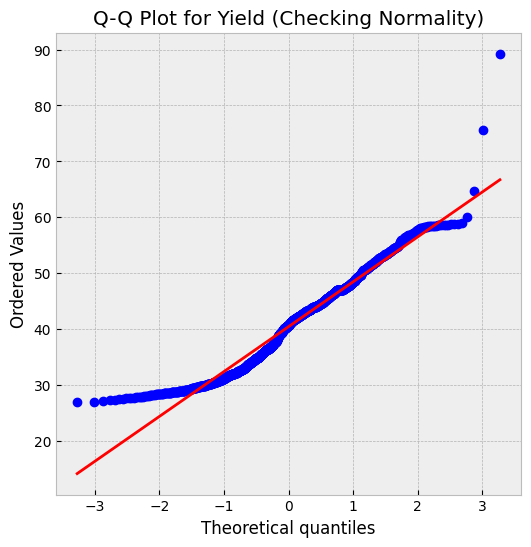

Verdict: Data is Non-Parametric (Reject Normality)


In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# 1. Perform Shapiro-Wilk Test
# Assuming 'y_train' is your yield dataframe
stat, p = stats.shapiro(y_train)

print(f"Shapiro-Wilk Statistic: {stat:.4f}")
print(f"P-Value: {p:.4e}")

# 2. Visual Proof (Q-Q Plot)
plt.figure(figsize=(6, 6))
stats.probplot(y_train, dist="norm", plot=plt)
plt.title('Q-Q Plot for Yield (Checking Normality)')
plt.show()

# 3. Decision Logic
if p < 0.05:
    print("Verdict: Data is Non-Parametric (Reject Normality)")
else:
    print("Verdict: Data is Parametric (Fail to Reject Normality)")

       Predictor  Spearman Rho      P-Value  MI Score   Dependency
3       rainfall         0.810  1.2256e-302     2.108  Significant
0           NDVI         0.430   8.9523e-60     1.455  Significant
1  soil_moisture        -0.349   1.9465e-38     0.845  Significant
2    temperature         0.021   4.3917e-01     0.042  Independent


/tmp/ipykernel_556/921425787.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MI Score', y='Predictor', data=dependency_df, palette='viridis')


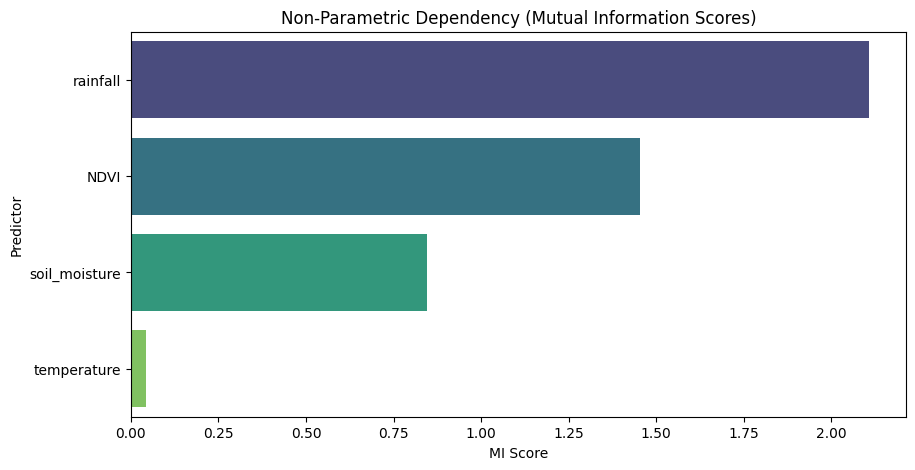

In [ ]:
import pandas as pd
from scipy.stats import spearmanr
from sklearn.feature_selection import mutual_info_regression

# 1. Prepare Data (using your finalized columns)
# Ensure y_train is loaded as your target
predictors = ['NDVI', 'soil_moisture', 'temperature', 'rainfall']
results = []

for col in predictors:
    # Spearman Test
    rho, p_value = spearmanr(X_train[col], y_train)

    # Mutual Information Test (Non-linear dependency)
    # n_neighbors=3 is standard for capturing local dependencies
    mi_score = mutual_info_regression(X_train[[col]], y_train.values.ravel(), random_state=42)[0]

    results.append({
        'Predictor': col,
        'Spearman Rho': round(rho, 3),
        'P-Value': f"{p_value:.4e}",
        'MI Score': round(mi_score, 3),
        'Dependency': 'Significant' if p_value < 0.05 else 'Independent'
    })

# 2. Display Results
dependency_df = pd.DataFrame(results).sort_values(by='MI Score', ascending=False)
print(dependency_df)

# 3. Visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.barplot(x='MI Score', y='Predictor', data=dependency_df, palette='viridis')
plt.title('Non-Parametric Dependency (Mutual Information Scores)')
plt.show()

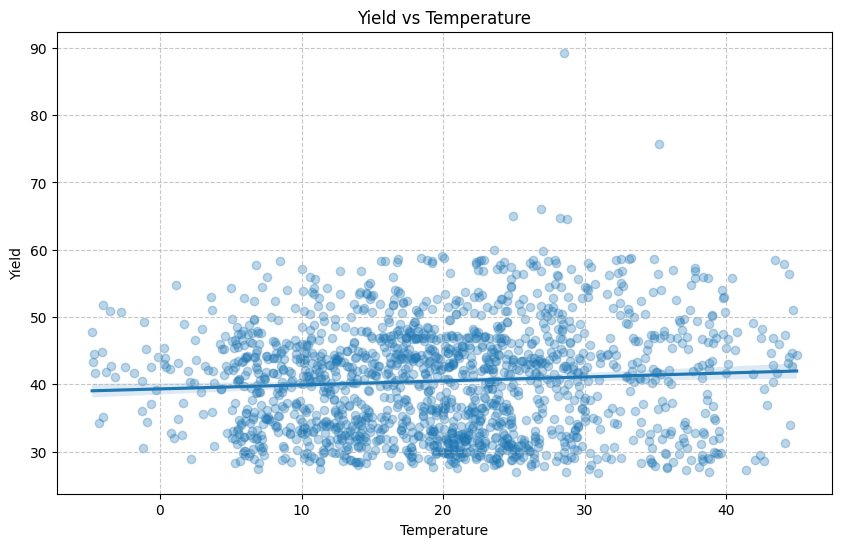

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot of Temperature vs Yield
plt.figure(figsize=(10, 6))
sns.regplot(x='temperature', y='yield', data=df, scatter_kws={'alpha':0.3})
plt.title('Yield vs Temperature')
plt.xlabel('Temperature')
plt.ylabel('Yield')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

/tmp/ipython-input-770/3266475499.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='crop_type', y='temperature', data=df, palette='viridis', order=median_temp_order)


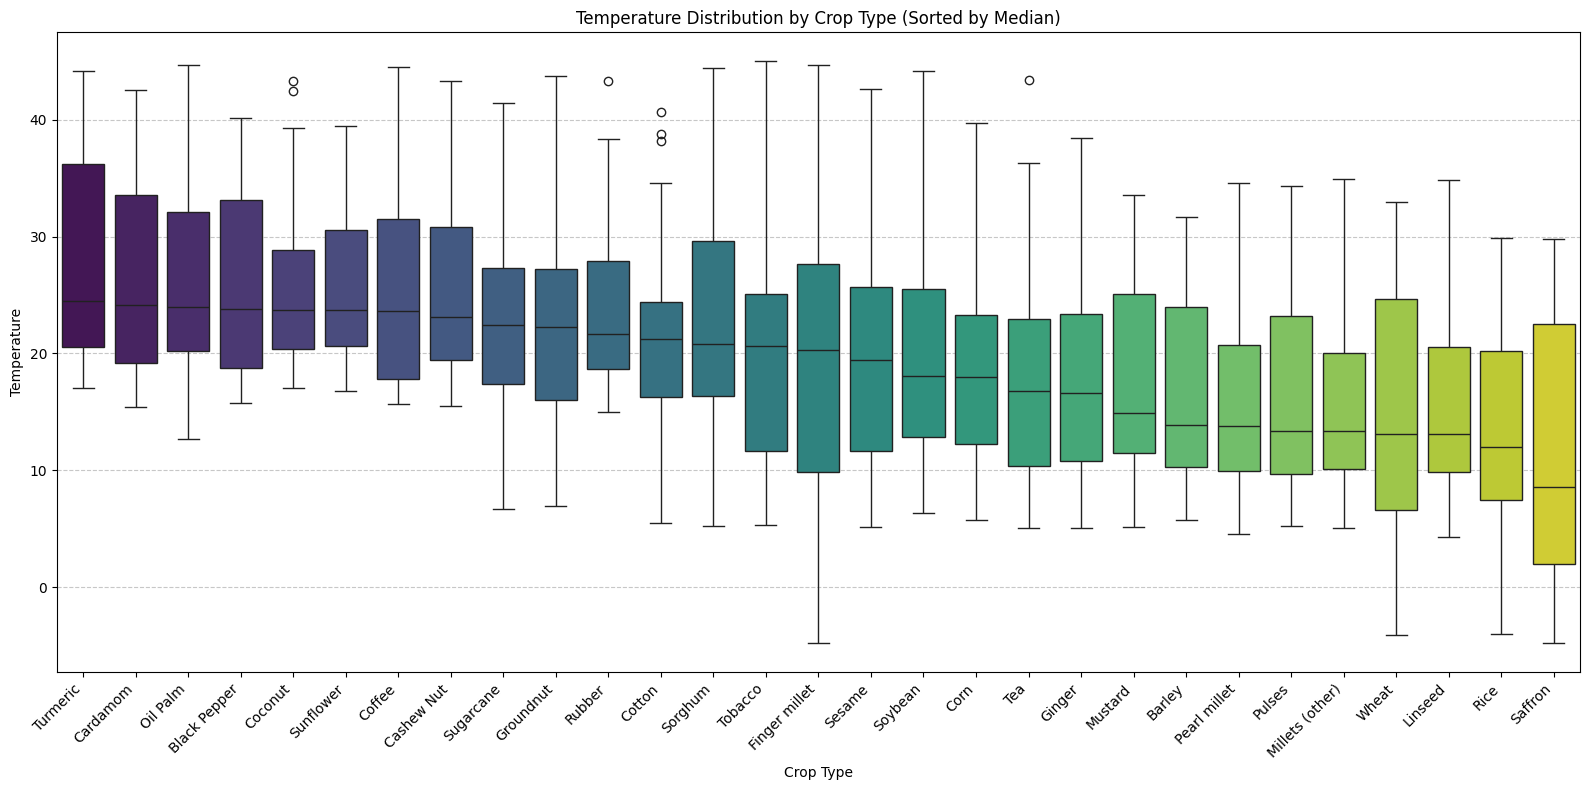

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate median temperature for each crop type to sort the plot
median_temp_order = df.groupby('crop_type')['temperature'].median().sort_values(ascending=False).index

# Box plot of Temperature by Crop Type, sorted by median temperature
plt.figure(figsize=(16, 8))
sns.boxplot(x='crop_type', y='temperature', data=df, palette='viridis', order=median_temp_order)
plt.title('Temperature Distribution by Crop Type (Sorted by Median)')
plt.xlabel('Crop Type')
plt.ylabel('Temperature')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import kruskal

# 1. Prepare the groups (Yields for each crop)
# We need 'crop_type' for the Kruskal-Wallis test.
# Since df_train was created from df_encoded (which dropped 'crop_type'),
# we retrieve the original 'crop_type' and 'yield' directly from the main 'df'
# using the training indices (X_train.index).
df_kruskal_data = df.loc[X_train.index][['crop_type', 'yield']].copy()

groups = [df_kruskal_data[df_kruskal_data['crop_type'] == crop]['yield']
          for crop in df_kruskal_data['crop_type'].unique()]

# 2. Perform the test
h_stat, p_val = kruskal(*groups)

print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
print(f"P-value: {p_val:.4e}")

if p_val < 0.05:
    print("Verdict: Significant Dependency (Non-Parametric Proof)")
else:
    print("Verdict: Independent")

Kruskal-Wallis H-statistic: 155.9977
P-value: 1.0146e-19
Verdict: Significant Dependency (Non-Parametric Proof)


In [8]:
cols_to_drop = ['temperature']
X_train_final = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test_final = X_test.drop(columns=cols_to_drop, errors='ignore')

# Save the finalized training and testing features
X_train_final.to_csv('X_train_final.csv', index=False)
X_test_final.to_csv('X_test_final.csv', index=False)

In [ ]:
X_train_final.to_csv('python_train_data01.csv', index=False)

In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 1. Load the final filtered training data
X_train_final = pd.read_csv('X_train_final.csv')

# 2. Prepare data for VIF
# Exclude non-numeric/ID columns and drop one dummy to avoid the trap
X_vif = X_train_final.copy()

# Explicitly drop identifier columns before VIF calculation
cols_to_drop_for_vif = ['field_id', 'date_of_image']
X_vif = X_vif.drop(columns=[col for col in cols_to_drop_for_vif if col in X_vif.columns])

crop_cols = [col for col in X_vif.columns if col.startswith('crop_')]
# Ensure there are crop columns to drop before attempting to drop
if crop_cols:
    X_vif = X_vif.drop(columns=[crop_cols[0]])

# 3. Add constant and calculate VIF
X_vif_const = add_constant(X_vif.astype(float))
vif_df = pd.DataFrame()
vif_df["Feature"] = X_vif_const.columns
vif_df["VIF Score"] = [variance_inflation_factor(X_vif_const.values, i)
                        for i in range(len(X_vif_const.columns))]

# 4. Clean up the table
vif_df = vif_df[vif_df["Feature"] != "const"].sort_values(by="VIF Score", ascending=False)
vif_df = vif_df.reset_index(drop=True)

# 5. Apply custom styling to highlight VIF scores > 20
def highlight_vif(s):
    is_high_vif = s > 20
    return ['background-color: red' if v else '' for v in is_high_vif]

styled_vif = vif_df.style.apply(highlight_vif, subset=['VIF Score']) \
                         .background_gradient(cmap='YlOrRd', subset=['VIF Score']) \
                         .format({'VIF Score': '{:.2f}'}) \
                         .set_caption("Variance Inflation Factor (VIF) Analysis (Highlights VIF > 20)")

# Display styled table
styled_vif

,Feature,VIF Score
0,soil_moisture,16.92
1,NDVI,14.87
2,crop_Sorghum,2.60
3,crop_Coconut,2.05
4,crop_Saffron,2.04
5,crop_Wheat,1.92
6,crop_Mustard,1.91
7,crop_Millets (other),1.91
8,crop_Pearl millet,1.90
9,crop_Soybean,1.89


--- Descriptive Statistics ---
                count       mean        std        min        25%        50%  \
NDVI           1300.0   0.359758   0.220529  -1.000000   0.234228   0.361183   
soil_moisture  1300.0  28.339682  14.029005   4.433631  19.534297  26.275436   
rainfall       1300.0   9.493388   5.060080   0.243661   6.182556   7.951453   
yield          1300.0  40.400835   8.187942  26.853751  33.037730  40.677069   

                     75%         max  
NDVI            0.504285    0.835025  
soil_moisture  33.491748  102.128741  
rainfall       13.095390   93.367483  
yield          46.104678   89.293417  

--- Outlier Detection Report ---
        Variable  Outlier Count  Percentage (%)  Lower Bound  Upper Bound
0           NDVI             28            1.79        -0.17         0.91
1  soil_moisture             70            4.49        -1.40        54.43
2       rainfall             11            0.71        -4.19        23.46
3          yield              2            

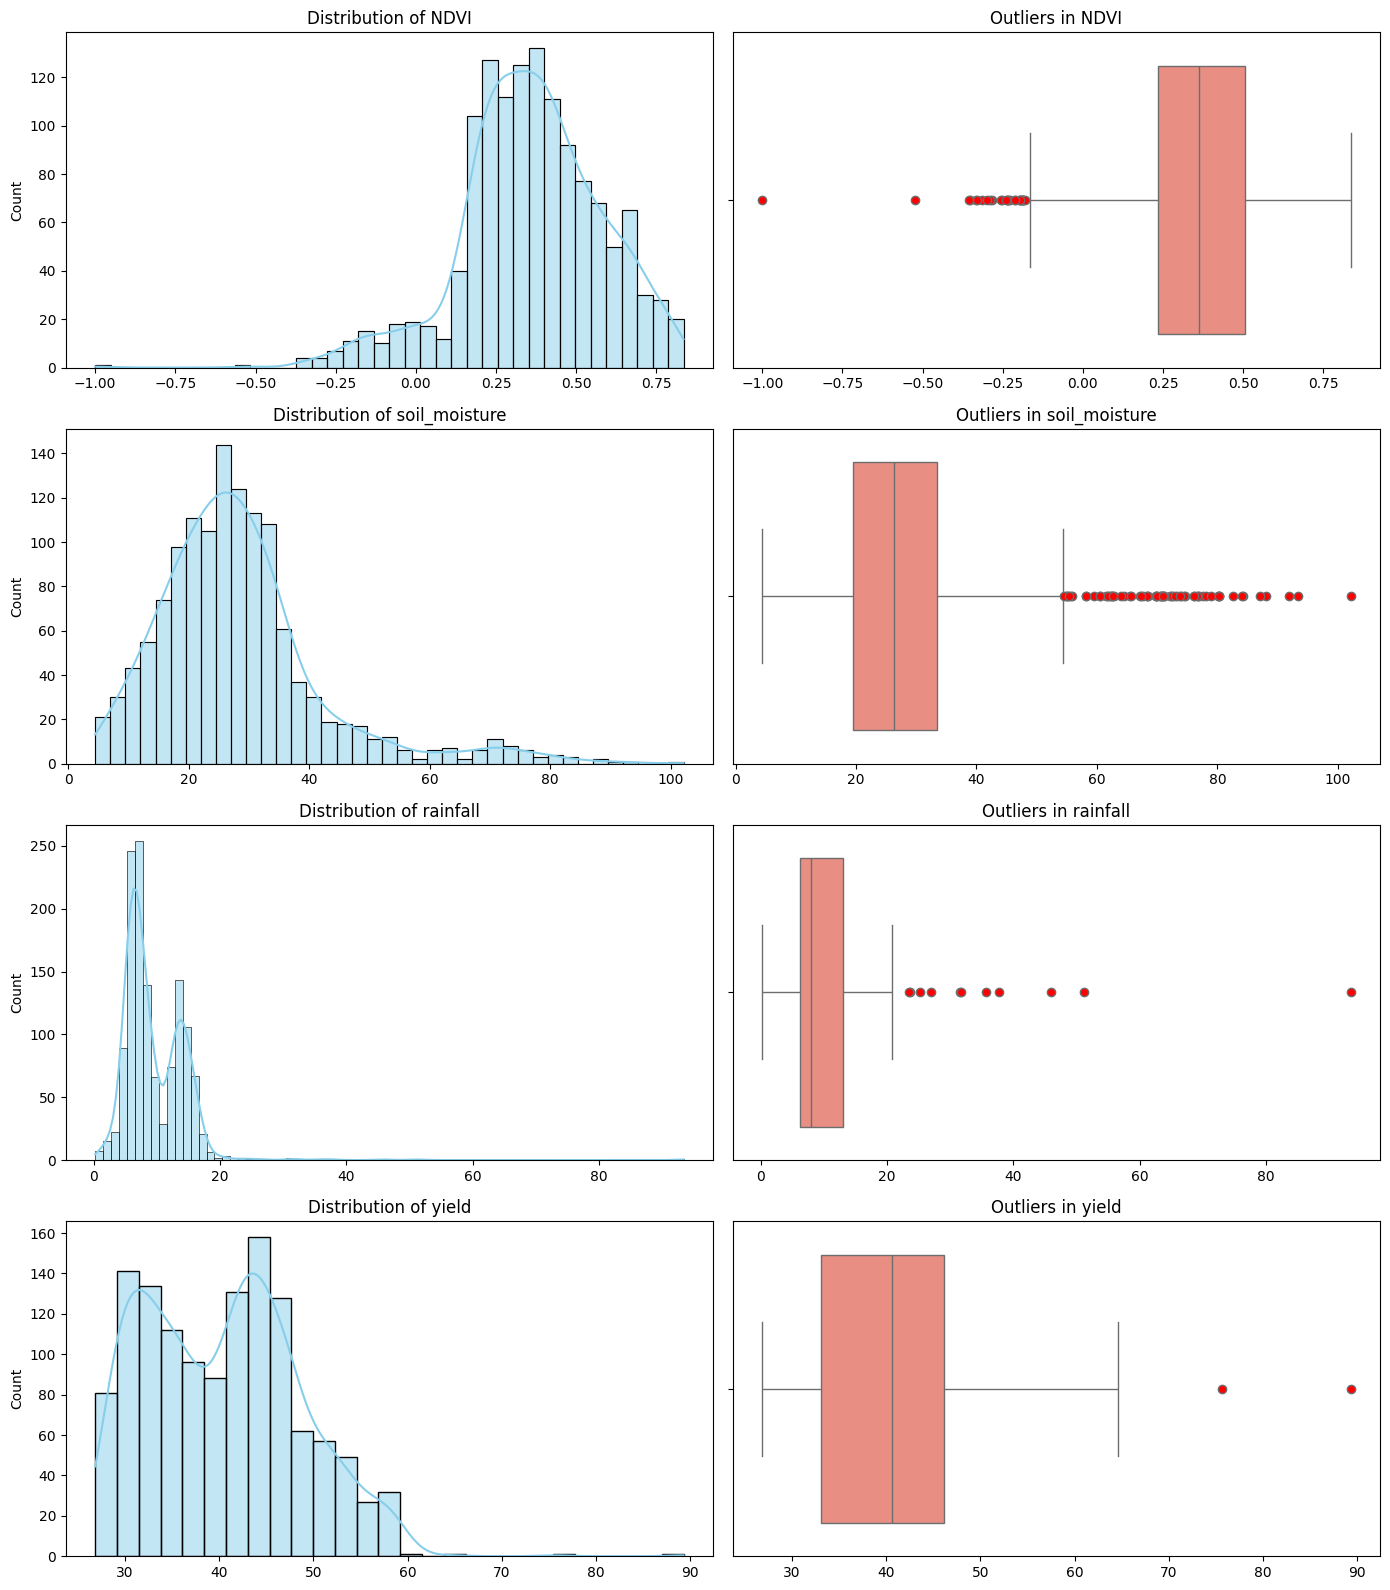

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the finalized training data
# This includes latitude, longitude, NDVI, soil_moisture, temperature, rainfall, and yield
X_train = pd.read_csv('X_train_final.csv')
# y_train = pd.read_csv('y_train.csv') # y_train is already in memory from the split

# Combine features and target for a complete univariate analysis
df_analysis = pd.concat([X_train, y_train], axis=1)

# List of numeric variables to analyze
# Note: 'latitude' and 'longitude' were dropped from X_train_final, so they should not be in numeric_vars.
numeric_vars = ['NDVI','soil_moisture', 'rainfall', 'yield'] # Updated numeric_vars

# 2. Descriptive Statistics Table
stats_table = df_analysis[numeric_vars].describe().T
print("--- Descriptive Statistics ---")
print(stats_table)

# 3. Outlier Detection using IQR Method
# Formula: Lower Bound = Q1 - 1.5 * IQR | Upper Bound = Q3 + 1.5 * IQR
outlier_results = []

for col in numeric_vars:
    Q1 = df_analysis[col].quantile(0.25)
    Q3 = df_analysis[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df_analysis[(df_analysis[col] < lower_bound) | (df_analysis[col] > upper_bound)]

    outlier_results.append({
        'Variable': col,
        'Outlier Count': len(outliers),
        'Percentage (%)': round((len(outliers) / len(df_analysis)) * 100, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2)
    })

outlier_df = pd.DataFrame(outlier_results)
print("\n--- Outlier Detection Report ---")
print(outlier_df)

# 4. Visualization: Histograms and Boxplots
# We create a grid of plots to visualize distribution and outliers simultaneously
fig, axes = plt.subplots(len(numeric_vars), 2, figsize=(14, 4 * len(numeric_vars)))

for i, col in enumerate(numeric_vars):
    # Histogram with Kernel Density Estimate (KDE)
    sns.histplot(df_analysis[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Distribution of {col}', fontsize=12)
    axes[i, 0].set_xlabel('')

    # Boxplot to highlight outliers
    sns.boxplot(x=df_analysis[col], ax=axes[i, 1], color='salmon', flierprops={'marker': 'o', 'markerfacecolor': 'red'})
    axes[i, 1].set_title(f'Outliers in {col}', fontsize=12)
    axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.savefig('univariate_and_outliers.png')
plt.show()

# 5. Export reports
stats_table.to_csv('descriptive_stats.csv')
outlier_df.to_csv('outlier_report.csv', index=False)

/tmp/ipython-input-159335877.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crop_pct.index, y=crop_pct.values, palette='viridis')


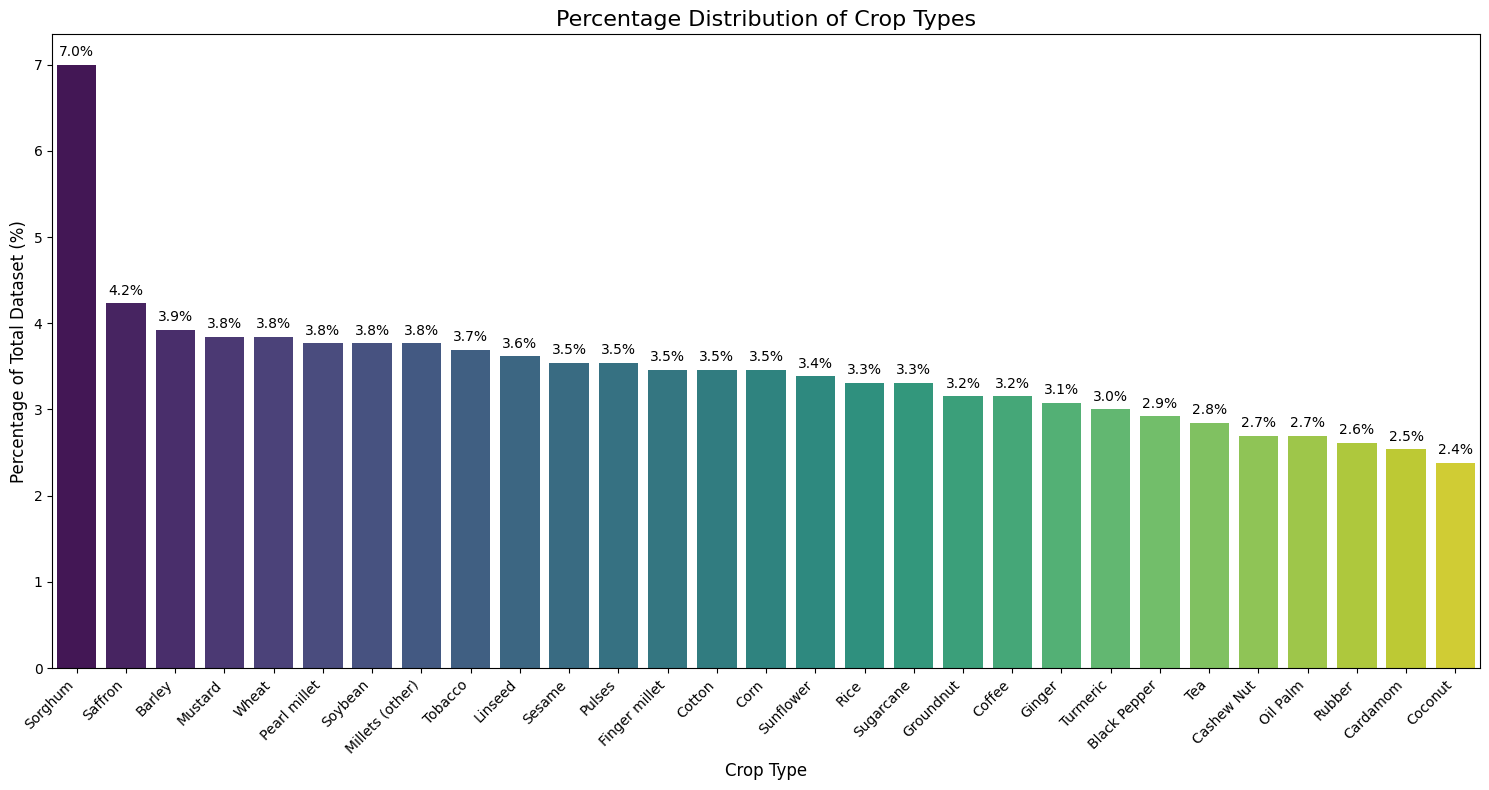

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reverse One-Hot Encoding
crop_cols = [col for col in X_train.columns if col.startswith('crop_')]
crop_series = X_train[crop_cols].idxmax(axis=1).str.replace('crop_', '')

# 2. Calculate Percentages
crop_pct = (crop_series.value_counts() / len(crop_series)) * 100

# 3. Create the Plot
plt.figure(figsize=(15, 8))
sns.barplot(x=crop_pct.index, y=crop_pct.values, palette='viridis')

# Add labels
plt.title('Percentage Distribution of Crop Types', fontsize=16)
plt.ylabel('Percentage of Total Dataset (%)', fontsize=12)
plt.xlabel('Crop Type', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add percentage text on top of bars
for i, v in enumerate(crop_pct.values):
    plt.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

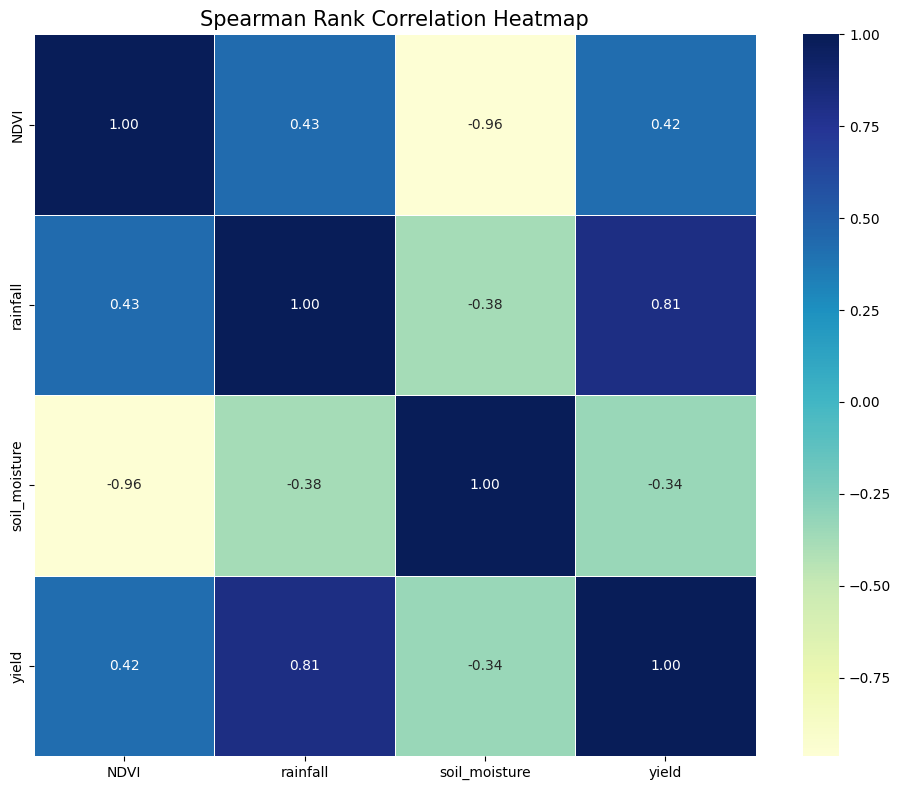

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select the variables
cols = ['NDVI', 'rainfall', 'soil_moisture', 'yield']
corr_data = df[cols]

# 2. Calculate Spearman Rank Correlation
# method='spearman' handles non-linear but monotonic relationships
spearman_corr = corr_data.corr(method='spearman')

# 3. Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr,
            annot=True,      # Show the numeric correlation values
            cmap='YlGnBu',   # Yellow-Green-Blue palette (good for agriculture)
            center=0,
            fmt='.2f',
            linewidths=0.5,
            square=True)

plt.title('Spearman Rank Correlation Heatmap', fontsize=15)
plt.tight_layout()

# 4. Save the plot
plt.savefig('spearman_heatmap.png')

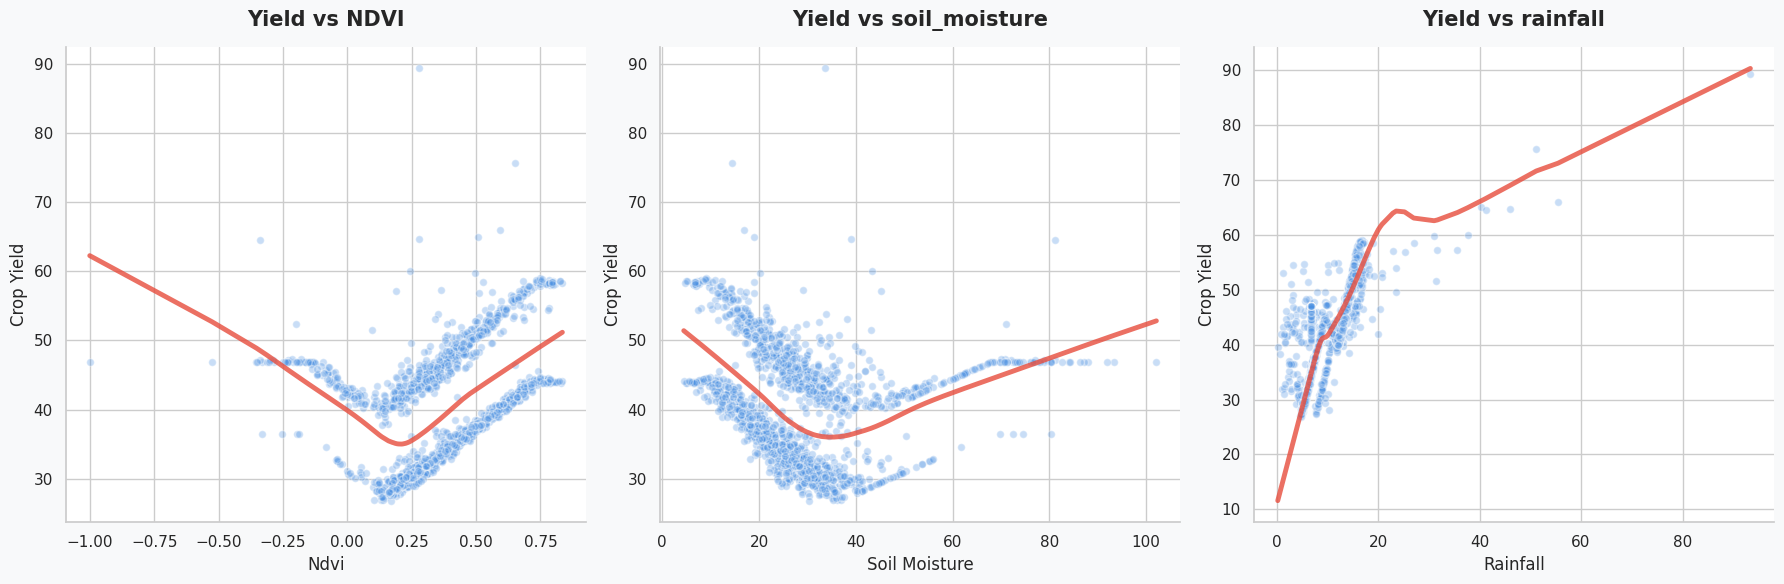

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set the aesthetic theme
sns.set_theme(style="whitegrid", palette="muted")

features = ['NDVI', 'soil_moisture', 'rainfall']

# 2. Create the figure with a better background color
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#f8f9fa')

for i, var in enumerate(features):
    # sns.regplot with styling refinements
    sns.regplot(
        x=var, y='yield', data=df, ax=axes[i],
        lowess=True,
        scatter_kws={'alpha':0.3, 's': 30, 'edgecolor': 'w', 'color': '#4a90e2'},
        line_kws={'color': '#e74c3c', 'lw': 3.5, 'alpha': 0.8}
    )

    # 3. Refine titles and labels
    axes[i].set_title(f'Yield vs {var}', fontsize=15, fontweight='bold', pad=15)
    axes[i].set_xlabel(var.replace('_', ' ').title(), fontsize=12)
    axes[i].set_ylabel('Crop Yield', fontsize=12)

    # Remove top and right spines for a "cleaner" look
    sns.despine(ax=axes[i])

plt.tight_layout()
plt.savefig('yield_non_parametric_trends.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipython-input-21944082.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='crop_type',
/tmp/ipython-input-21944082.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='crop_type',
/tmp/ipython-input-21944082.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='crop_type',


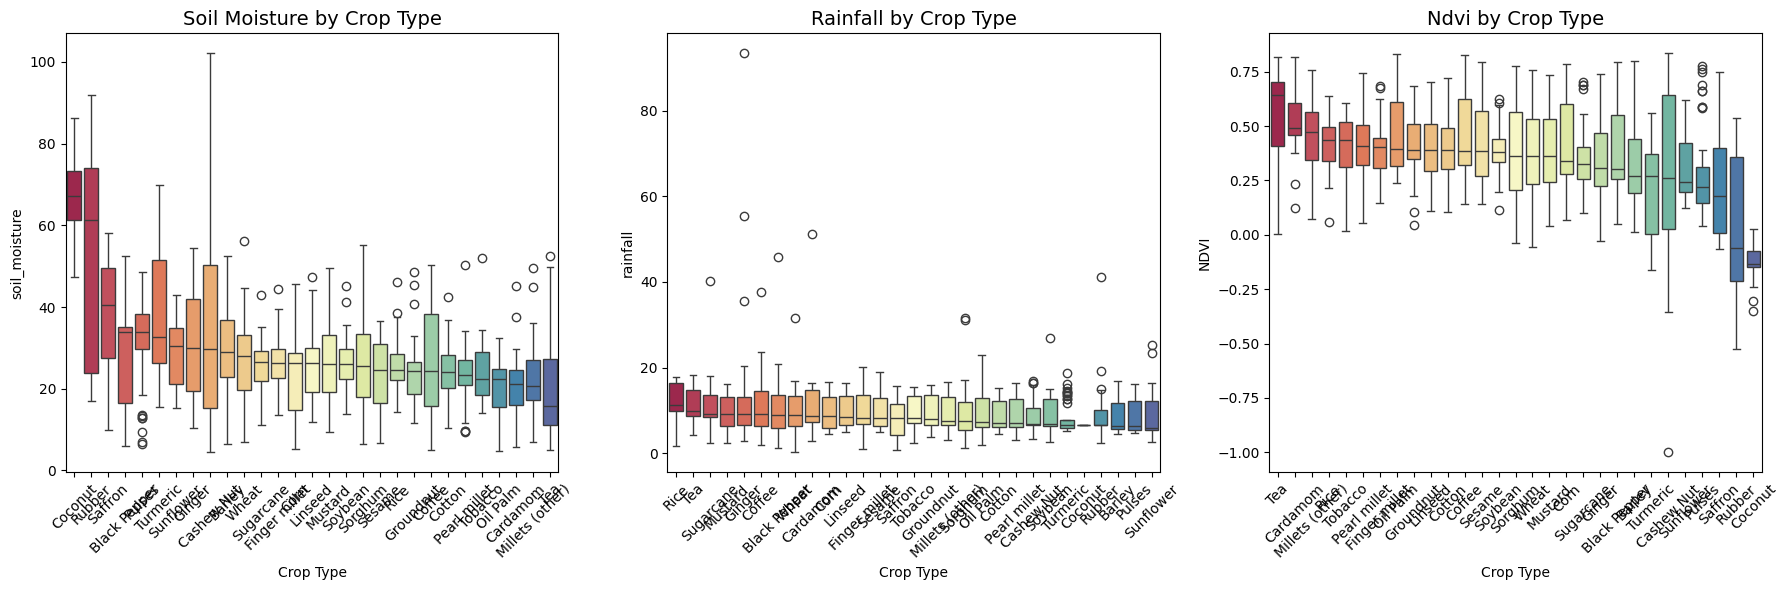

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Melt the dataframe to make it 'Long-form' (better for Seaborn)
# This allows us to create subplots easily
features = ['soil_moisture', 'rainfall', 'NDVI']
df_melted = df.melt(id_vars=['crop_type'],
                    value_vars=features,
                    var_name='Variable',
                    value_name='Value')

# 2. Set up the figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

# 3. Create a box plot for each feature
for i, var in enumerate(features):
    order = df.groupby('crop_type')[var].median().sort_values(ascending=False).index
    sns.boxplot(x='crop_type',
                y=var,
                data=df[df['crop_type'].notnull()],
                ax=axes[i],
                order=order,
                palette='Spectral')

    axes[i].set_title(f'{var.replace("_", " ").title()} by Crop Type', fontsize=14)
    axes[i].set_xlabel('Crop Type')
    axes[i].set_ylabel(var)
    # Rotate x-labels if you have many crop types
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('environmental_boxplots_by_crop.png')

/tmp/ipython-input-1723509481.py:14: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  train_df['crop_type'] = train_df[crop_cols].idxmax(axis=1).str.replace('crop_', '')
/tmp/ipython-input-1723509481.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


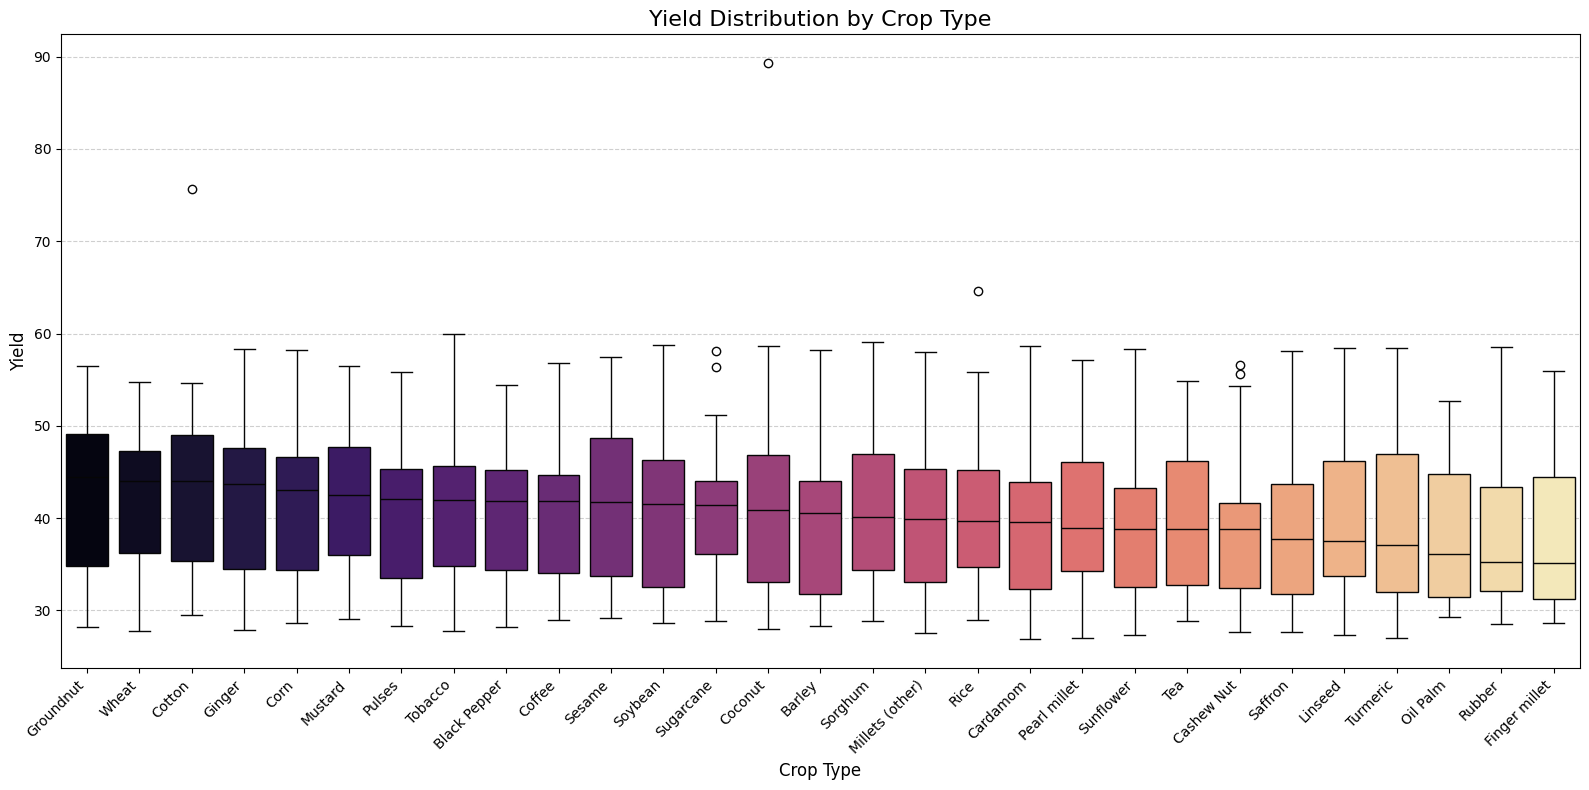

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Combine X_train and y_train to ensure data alignment
# This creates a fresh dataframe for plotting from your 80% training split
train_df = pd.concat([X_train, y_train], axis=1)

# 2. Identify the one-hot encoded crop columns
crop_cols = [col for col in train_df.columns if col.startswith('crop_')]

# 3. Create a single 'crop_type' column for the X-axis
# .idxmax(axis=1) finds which column has the '1' for each row
train_df['crop_type'] = train_df[crop_cols].idxmax(axis=1).str.replace('crop_', '')

# 4. Calculate the median yield per crop to sort the plot
# Sorting makes it immediately obvious which crops are high/low producers
order = train_df.groupby('crop_type')['yield'].median().sort_values(ascending=False).index

# 5. Generate the Box Plot
plt.figure(figsize=(16, 8))
sns.boxplot(
    data=train_df,
    x='crop_type',
    y='yield',
    order=order,
    palette='magma',
    showfliers=True  # Ensure outliers are visible as they are important for ADA
)

plt.title('Yield Distribution by Crop Type', fontsize=16)
plt.xlabel('Crop Type', fontsize=12)
plt.ylabel('Yield', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [9]:
# First, install the library if you haven't: !pip install prince
!pip install prince


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.5/179.5 kB 8.5 MB/s eta 0:00:00


In [10]:
import pandas as pd

# Load X_train_final.csv which contains the processed features including crop dummy variables
X_famd_data = pd.read_csv('X_train_final.csv')

# Reconstruct the 'crop_type' column from the dummy variables for FAMD
crop_cols = [col for col in X_famd_data.columns if col.startswith('crop_')]
X_famd_data['crop_type'] = X_famd_data[crop_cols].idxmax(axis=1).str.replace('crop_', '')

# Select the features for FAMD, including the new 'crop_type' categorical column
X_input = X_famd_data[['NDVI', 'soil_moisture', 'rainfall', 'crop_type']]

print("X_input DataFrame created successfully.")

X_input DataFrame created successfully.


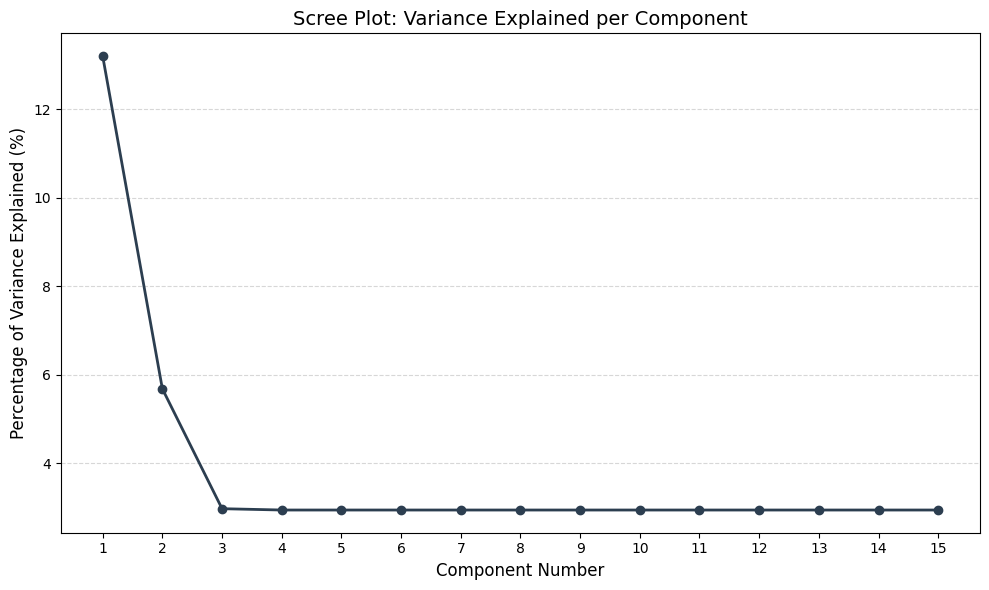

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from prince import FAMD

# 1. Initialize FAMD
# We'll check the first 15 components to see the drop-off
famd = FAMD(n_components=15, random_state=42)
famd = famd.fit(X_input) # X_input should contain NDVI, rainfall, and crop_type

# 2. Extract Variance Explained
# prince stores this in eigenvalues_summary
# Convert '% of variance' from string to float for numerical operations
var_explained = famd.eigenvalues_summary['% of variance'].str.replace('%', '').astype(float)

# 3. Create the Downward Scree Plot
plt.figure(figsize=(10, 6))

# Line plot with markers
plt.plot(range(1, len(var_explained) + 1), var_explained,
         marker='o', linestyle='-', color='#2c3e50', linewidth=2)

# 4. Styling and Labels
plt.title('Scree Plot: Variance Explained per Component', fontsize=14)
plt.xlabel('Component Number', fontsize=12)
plt.ylabel('Percentage of Variance Explained (%)', fontsize=12)
plt.xticks(range(1, len(var_explained) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

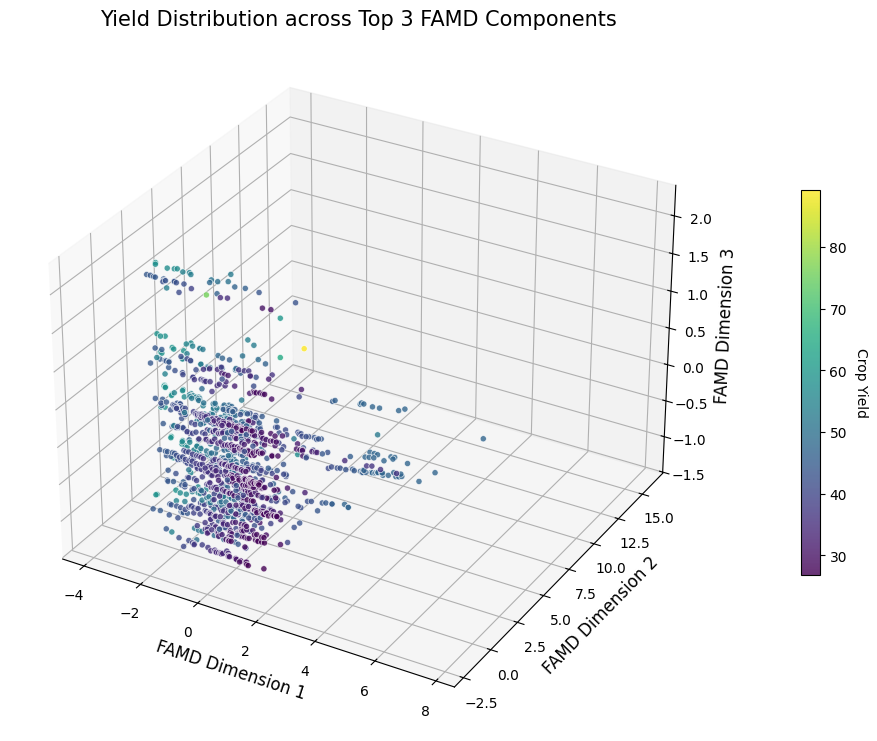

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Transform the data into the 3 components
# We fit/transform to get the coordinates for each field
famd_3 = FAMD(n_components=3, random_state=42)
famd_coords = famd_3.fit_transform(X_input)

# 2. Rename columns for clarity
famd_coords.columns = ['FAMD_Dim_1', 'FAMD_Dim_2', 'FAMD_Dim_3']

# 3. Add the Yield column for coloring
famd_coords['Yield'] = y_train.values

# 4. Create the 3D Scatter Plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(famd_coords['FAMD_Dim_1'],
                     famd_coords['FAMD_Dim_2'],
                     famd_coords['FAMD_Dim_3'],
                     c=famd_coords['Yield'],
                     cmap='viridis',
                     alpha=0.8,         # slightly increased alpha to pop out in 3D
                     edgecolors='w',
                     linewidth=0.5)

# Add a colorbar to show yield intensity
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label('Crop Yield', rotation=270, labelpad=15)

ax.set_title('Yield Distribution across Top 3 FAMD Components', fontsize=15)
ax.set_xlabel('FAMD Dimension 1', fontsize=12)
ax.set_ylabel('FAMD Dimension 2', fontsize=12)
ax.set_zlabel('FAMD Dimension 3', fontsize=12)

plt.show()

For n_clusters = 2, Silhouette Score: 0.3123
For n_clusters = 3, Silhouette Score: 0.3206
For n_clusters = 4, Silhouette Score: 0.3309
For n_clusters = 5, Silhouette Score: 0.3321
For n_clusters = 6, Silhouette Score: 0.3146
For n_clusters = 7, Silhouette Score: 0.3064
For n_clusters = 8, Silhouette Score: 0.2943
For n_clusters = 9, Silhouette Score: 0.2862
For n_clusters = 10, Silhouette Score: 0.2890


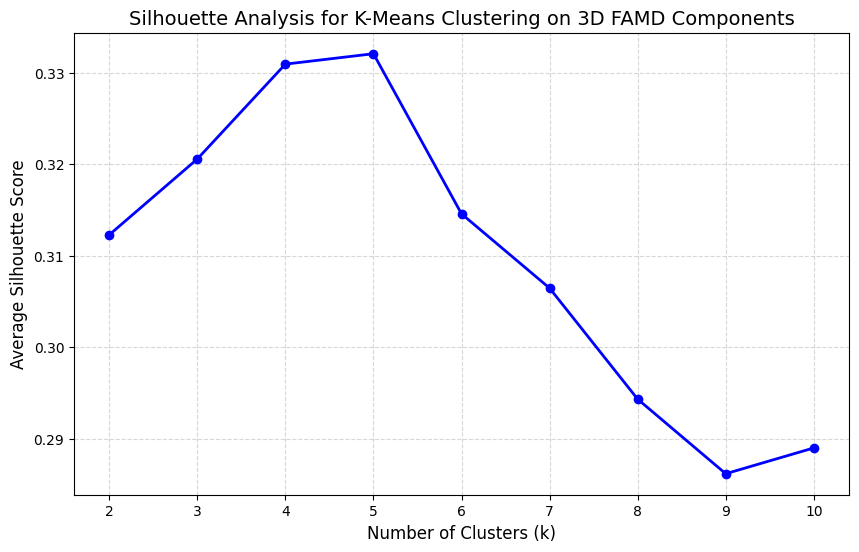

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Prepare your FAMD coordinates (famd_3d_coords is already defined)
X_clustering_3d = famd_3d_coords.copy()

range_n_clusters = range(2, 11)
silhouette_avg_scores = []

# 2. Loop to find the best K
for n_clusters in range_n_clusters:
    # Initialize KMeans
    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = clusterer.fit_predict(X_clustering_3d)

    # Calculate the average silhouette score
    silhouette_avg = silhouette_score(X_clustering_3d, cluster_labels)
    silhouette_avg_scores.append(silhouette_avg)
    print(f"For n_clusters = {n_clusters}, Silhouette Score: {silhouette_avg:.4f}")

# 3. Plot the Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, silhouette_avg_scores, marker='o', color='blue', linewidth=2)
plt.title('Silhouette Analysis for K-Means Clustering on 3D FAMD Components', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Average Silhouette Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [ ]:
from sklearn.cluster import KMeans

# 1. Identify the optimal number of clusters (k) from the previous silhouette analysis.
# Based on the output, k=5 had the highest silhouette score: 0.3321
optimal_k = 5

# 2. Initialize a KMeans model
clusterer = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# 3. Fit the KMeans model to the X_clustering_3d (famd_3d_coords) and predict the cluster labels.
cluster_labels = clusterer.fit_predict(X_clustering_3d)

# 4. Store the resulting cluster labels in a new column named 'Cluster' within the famd_3d_coords DataFrame.
famd_3d_coords['Cluster'] = cluster_labels

print(f"K-Means clustering applied with {optimal_k} clusters.")
print("First 5 rows of famd_3d_coords with new 'Cluster' column:")
print(famd_3d_coords.head())

K-Means clustering applied with 5 clusters.
First 5 rows of famd_3d_coords with new 'Cluster' column:
   FAMD_Dim_1  FAMD_Dim_2  FAMD_Dim_3  Cluster
0    0.213358    0.374049   -0.218827        4
1    0.039103   -0.318184    0.352822        1
2    1.359362   -0.658757   -0.502297        1
3    0.169032   -0.633320   -0.778430        1
4    0.038500   -0.451137    1.135275        1


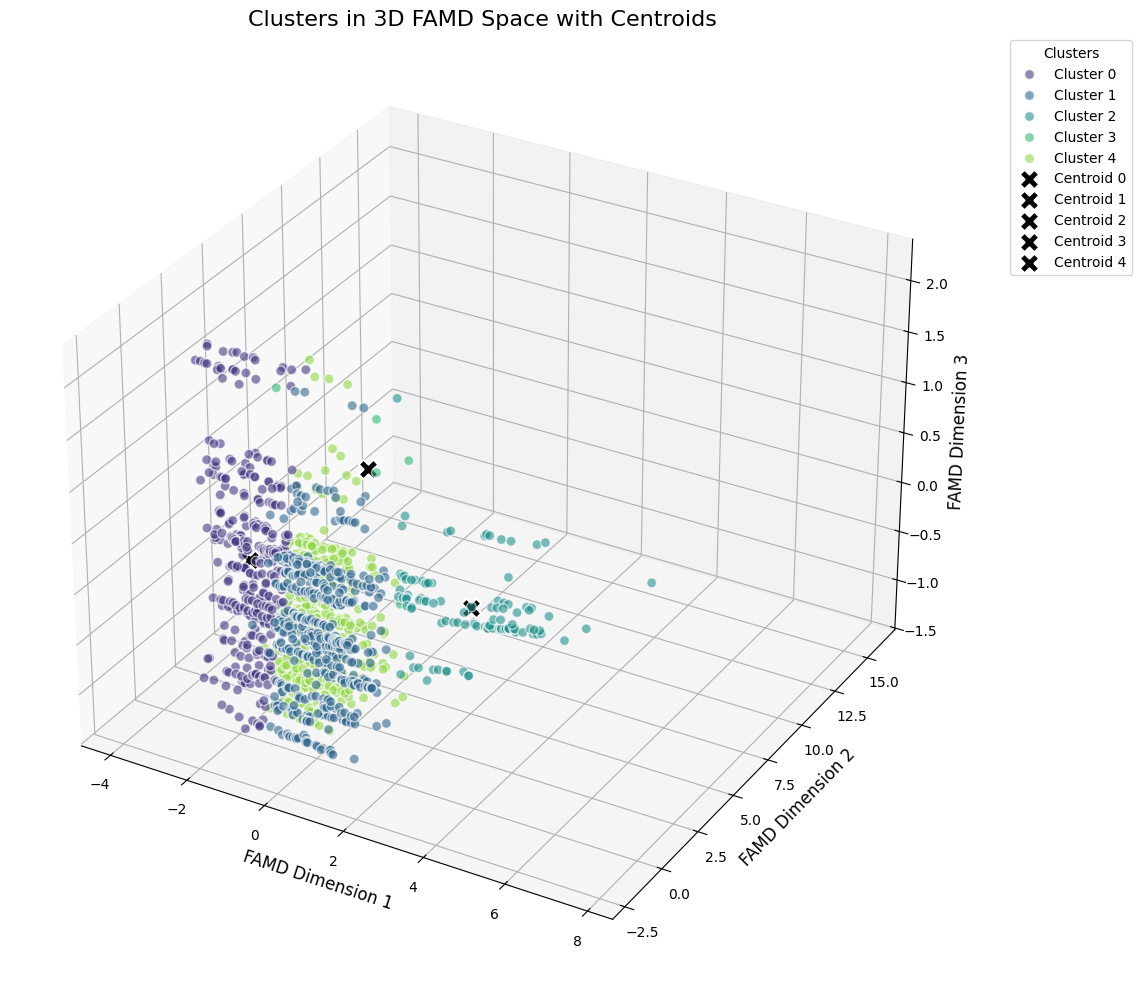

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Ensure X_clustering_3d contains the FAMD dimensions and the 'Cluster' column
# This was done in the previous step where famd_3d_coords was updated with 'Cluster'
# So, famd_3d_coords is our X_clustering_3d for plotting

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Get unique cluster labels and a color palette
unique_clusters = sorted(famd_3d_coords['Cluster'].unique())
palette = sns.color_palette('viridis', n_colors=len(unique_clusters))

# Plot each cluster
for cluster_id in unique_clusters:
    subset = famd_3d_coords[famd_3d_coords['Cluster'] == cluster_id]
    ax.scatter(
        subset['FAMD_Dim_1'],
        subset['FAMD_Dim_2'],
        subset['FAMD_Dim_3'],
        c=[palette[cluster_id]], # Use the color from the palette
        label=f'Cluster {cluster_id}',
        s=50, alpha=0.6, edgecolors='w'
    )

# Optionally, plot the cluster centroids
# First, re-fit KMeans to get the centroids after clustering famd_3d_coords
from sklearn.cluster import KMeans
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_model.fit(famd_3d_coords[['FAMD_Dim_1', 'FAMD_Dim_2', 'FAMD_Dim_3']])
centroids = kmeans_model.cluster_centers_

for i, centroid in enumerate(centroids):
    ax.scatter(
        centroid[0], centroid[1], centroid[2],
        marker='X', s=200, color='black', label=f'Centroid {i}', edgecolors='w', linewidth=1.5
    )


ax.set_xlabel('FAMD Dimension 1', fontsize=12)
ax.set_ylabel('FAMD Dimension 2', fontsize=12)
ax.set_zlabel('FAMD Dimension 3', fontsize=12)
ax.set_title('Clusters in 3D FAMD Space with Centroids', fontsize=16)
ax.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

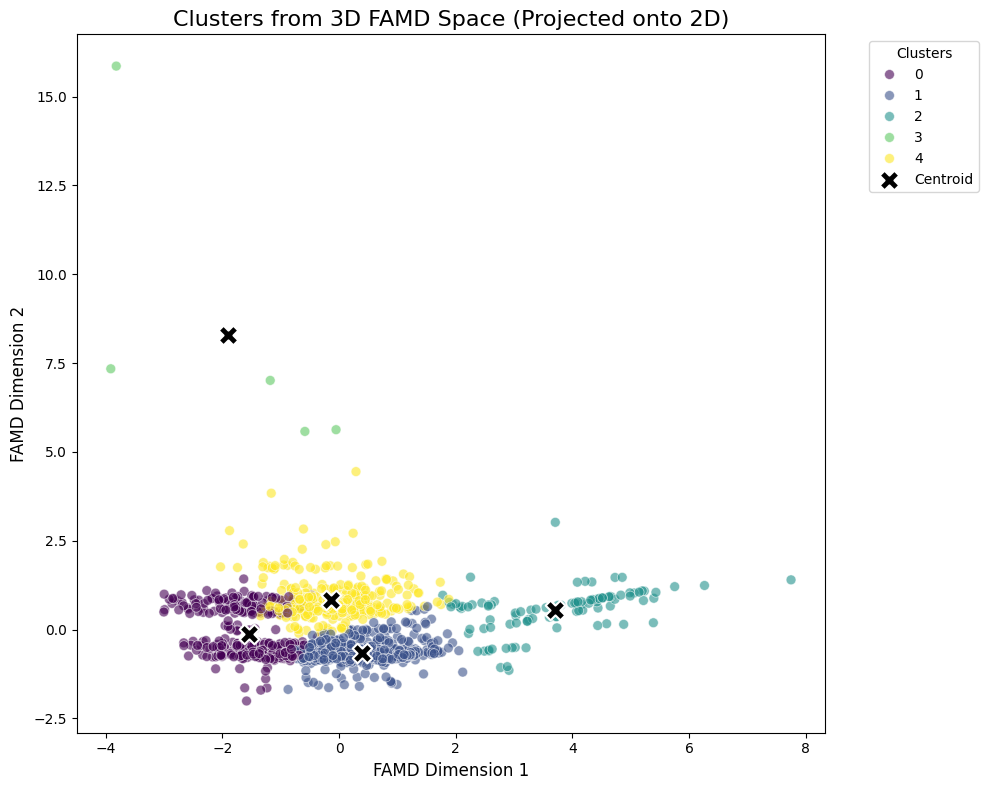

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Set up the figure
plt.figure(figsize=(10, 8))

# 1. Plot the data points in 2D
# We plot Dim 1 vs Dim 2, but color them by the clusters you found using 3D data
sns.scatterplot(
    data=famd_3d_coords,
    x='FAMD_Dim_1',
    y='FAMD_Dim_2',
    hue='Cluster',
    palette='viridis',
    alpha=0.6,
    edgecolor='w',
    s=50
)

# 2. Re-fit KMeans to get the centroids
# (Fitting on all 3 dimensions to match your original clustering)
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_model.fit(famd_3d_coords[['FAMD_Dim_1', 'FAMD_Dim_2', 'FAMD_Dim_3']])
centroids = kmeans_model.cluster_centers_

# 3. Plot the centroids in 2D
# We only use centroid[0] (Dim 1) and centroid[1] (Dim 2) for the 2D plot
for i, centroid in enumerate(centroids):
    plt.scatter(
        centroid[0], centroid[1],
        marker='X', s=200, color='black',
        edgecolors='w', linewidth=1.5,
        label='Centroid' if i == 0 else "" # Label only once to keep legend clean
    )

# 4. Formatting the plot
plt.xlabel('FAMD Dimension 1', fontsize=12)
plt.ylabel('FAMD Dimension 2', fontsize=12)
plt.title('Clusters from 3D FAMD Space (Projected onto 2D)', fontsize=16)

# Move legend outside the plot
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd # Import pandas for table styling
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

# 1. No Log Transformation on y
# y_train and y_test will be used directly (original scale)

# 2. Scaling Predictors (Essential for Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

# 3. Lasso with Cross-Validation to find the best Alpha
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train) # Use original y_train

# 4. Predictions (will be on original scale)
train_preds = lasso.predict(X_train_scaled)
test_preds = lasso.predict(X_test_scaled)

# 5. No Inverse Transform needed as predictions are on original scale
# train_final_preds = np.expm1(train_log_preds)
# test_final_preds = np.expm1(test_log_preds)

# 6. Metric Calculations
def get_adj_r2(y_true, y_pred, n, p):
    r2 = r2_score(y_true, y_pred)
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# n = samples, p = number of non-zero coefficients in Lasso
n_test = X_test_final.shape[0]
p_lasso = np.sum(lasso.coef_ != 0)

metrics = {
    "Train RMSE": np.sqrt(mean_squared_error(y_train, train_preds)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, test_preds)),
    "Train MAPE": mean_absolute_percentage_error(y_train, train_preds),
    "Test MAPE": mean_absolute_percentage_error(y_test, test_preds),
    "Train R2": r2_score(y_train, train_preds),
    "Test R2": r2_score(y_test, test_preds),
    "Adjusted R2": get_adj_r2(y_test, test_preds, n_test, p_lasso) # Use original y_test and test_preds
}

# Create a DataFrame for better display
perf_df = pd.DataFrame.from_dict(metrics, orient='index', columns=['Value'])

# Transpose the DataFrame to display metrics row-wise
perf_df_transposed = perf_df.T

# 7. Pretty Table Output
print("--- Lasso Model Performance (Original Scale Yield) ---")
display(perf_df_transposed.style.format('{:.4f}').set_caption("Lasso Regression Model Performance"))

print(f"\nOptimal Alpha: {lasso.alpha_:.6f}")
print(f"Features selected by Lasso: {p_lasso} out of {X_train_final.shape[1]}")

--- Lasso Model Performance (Original Scale Yield) ---


,Train RMSE,Test RMSE,Train MAPE,Test MAPE,Train R2,Test R2,Adjusted R2
Value,3.8620,3.8240,0.0728,0.0725,0.7774,0.7777,0.7591



Optimal Alpha: 0.026664
Features selected by Lasso: 25 out of 32


In [ ]:
import pandas as pd

# 1. Create a Series of coefficients with their corresponding feature names
# Assuming 'X_train' is your dataframe before scaling, so we have column names
coef_series = pd.Series(lasso.coef_, index=X_train.columns)

# 2. Filter for features where the coefficient is exactly 0
dropped_features = coef_series[coef_series == 0].index.tolist()
kept_features = coef_series[coef_series != 0].index.tolist()

# 3. Print the results
print(f"--- Lasso Feature Selection Summary ---")
print(f"Total Features: {len(coef_series)}")
print(f"Features Kept: {len(kept_features)}")
print(f"Features Dropped: {len(dropped_features)}")

print("\n--- List of Dropped Features ---")
for feature in dropped_features:
    print(f"❌ {feature}")

print("\n--- Top 5 Most Influential Kept Features ---")
print(coef_series.abs().sort_values(ascending=False).head(5))

--- Lasso Feature Selection Summary ---
Total Features: 32
Features Kept: 25
Features Dropped: 7

--- List of Dropped Features ---
❌ crop_Coffee
❌ crop_Corn
❌ crop_Cotton
❌ crop_Finger millet
❌ crop_Linseed
❌ crop_Oil Palm
❌ crop_Pearl millet

--- Top 5 Most Influential Kept Features ---
NDVI             9.593449
soil_moisture    8.006308
rainfall         5.551175
crop_Coconut     1.097613
crop_Rubber      0.529209
dtype: float64


In [ ]:
import numpy as np
import pandas as pd # Import pandas for DataFrame and styling
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

# 1. Initialize and Train Ridge (Using the same scaled data, but original y)
ridge = RidgeCV(alphas=[1e-3, 1e-2, 1e-1, 1, 10, 100], cv=5)
ridge.fit(X_train_scaled, y_train) # Use original y_train

# 2. Predictions (will be on original scale)
train_preds_ridge = ridge.predict(X_train_scaled)
test_preds_ridge = ridge.predict(X_test_scaled)

# 3. No Inverse Transform needed as predictions are on original scale
# train_final_preds_ridge = np.expm1(train_log_preds_ridge)
# test_final_preds_ridge = np.expm1(test_log_preds_ridge)

# 4. Calculate Metrics
n_ridge = X_test_final.shape[0] # Use X_test_final for n
p_ridge = X_test_final.shape[1] # Ridge keeps all features, so use all features in X_test_final

# Helper function for Adjusted R2 (assuming it's defined in a previous cell or globally available)
def get_adj_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

metrics_ridge = {
    "Train RMSE": np.sqrt(mean_squared_error(y_train, train_preds_ridge)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, test_preds_ridge)),
    "Train MAPE": mean_absolute_percentage_error(y_train, train_preds_ridge),
    "Test MAPE": mean_absolute_percentage_error(y_test, test_preds_ridge),
    "Train R2": r2_score(y_train, train_preds_ridge),
    "Test R2": r2_score(y_test, test_preds_ridge),
    "Adjusted R2": get_adj_r2(r2_score(y_test, test_preds_ridge), n_ridge, p_ridge) # Use original y_test and test_preds
}

# Create a DataFrame for better display
ridge_perf_df = pd.DataFrame.from_dict(metrics_ridge, orient='index', columns=['Value'])

# Transpose the DataFrame to display metrics row-wise
ridge_perf_df_transposed = ridge_perf_df.T

# 5. Pretty Table
print("--- Ridge Model Performance (Original Scale Yield) ---")
display(ridge_perf_df_transposed.style.format('{:.4f}').set_caption("Ridge Regression Model Performance"))

--- Ridge Model Performance (Original Scale Yield) ---


,Train RMSE,Test RMSE,Train MAPE,Test MAPE,Train R2,Test R2,Adjusted R2
Value,3.8557,3.8232,0.0720,0.0720,0.7781,0.7777,0.7534


In [ ]:
print(f"Optimal Alpha for Ridge: {ridge.alpha_:.6f}")

Optimal Alpha for Ridge: 0.100000


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

# Assuming X_train_scaled, X_test_scaled, y_train, y_test are already defined

# Helper function for Adjusted R2 (if not already defined)
def get_adj_r2(y_true, y_pred, n, p):
    r2 = r2_score(y_true, y_pred)
    # Avoid division by zero if p is too large (more features than samples) or n-p-1 <= 0
    if (n - p - 1) <= 0:
        return np.nan # Or handle appropriately
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# 1. Initialize and Train Elastic Net with Cross-Validation
# l1_ratio: The mixing parameter, with 0 <= l1_ratio <= 1.
# For l1_ratio = 0 the penalty is an L2 penalty. For l1_ratio = 1 it is an L1 penalty.
# For 0 < l1_ratio < 1, the penalty is a combination of L1 and L2.
# Here we try a range of l1_ratio values.
elastic_net = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1],
                           alphas=[1e-3, 1e-2, 1e-1, 1, 10, 100],
                           cv=5, random_state=42)
elastic_net.fit(X_train_scaled, y_train)

# 2. Predictions
train_preds_en = elastic_net.predict(X_train_scaled)
test_preds_en = elastic_net.predict(X_test_scaled)

# 3. Metric Calculations
n_en = X_test_final.shape[0]
p_en = np.sum(elastic_net.coef_ != 0) # Count non-zero coefficients for Adjusted R2

metrics_en = {
    "Train RMSE": np.sqrt(mean_squared_error(y_train, train_preds_en)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, test_preds_en)),
    "Train MAPE": mean_absolute_percentage_error(y_train, train_preds_en),
    "Test MAPE": mean_absolute_percentage_error(y_test, test_preds_en),
    "Train R2": r2_score(y_train, train_preds_en),
    "Test R2": r2_score(y_test, test_preds_en),
    "Adjusted R2": get_adj_r2(y_test, test_preds_en, n_en, p_en) # Corrected call
}

# Create a DataFrame for better display
en_perf_df = pd.DataFrame.from_dict(metrics_en, orient='index', columns=['Value'])
en_perf_df_transposed = en_perf_df.T

# 4. Pretty Table Output
print("--- Elastic Net Model Performance (Original Scale Yield) ---")
display(en_perf_df_transposed.style.format('{:.4f}').set_caption("Elastic Net Regression Model Performance"))

print(f"\nOptimal Alpha: {elastic_net.alpha_:.6f}")
print(f"Optimal L1 Ratio: {elastic_net.l1_ratio_:.2f}")
print(f"Features selected by Elastic Net: {p_en} out of {X_train_final.shape[1]}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7.662593118739096, tolerance: 6.993866980789162
  model = cd_fast.enet_coordinate_descent_gram(


--- Elastic Net Model Performance (Original Scale Yield) ---


,Train RMSE,Test RMSE,Train MAPE,Test MAPE,Train R2,Test R2,Adjusted R2
Value,3.8567,3.8231,0.0723,0.0722,0.7780,0.7778,0.7559



Optimal Alpha: 0.010000
Optimal L1 Ratio: 1.00
Features selected by Elastic Net: 29 out of 32


In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

# Prepare DataFrames for Decision Tree
# Use X_train_final and X_test_final directly, which already contain dummy variables
X_train_dt = X_train_final.copy()
X_test_dt = X_test_final.copy()

# No need for Label Encoding; dummy variables are already present in X_train_final/X_test_final.
# The original crop_cols and LabelEncoder steps are removed or commented out.

# Model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_dt, y_train)

# Predictions
train_preds = dt_model.predict(X_train_dt)
test_preds = dt_model.predict(X_test_dt)

# Metrics
n, p = X_test_dt.shape
r2 = r2_score(y_test, test_preds)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

metrics = {
    "Train RMSE": np.sqrt(mean_squared_error(y_train, train_preds)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, test_preds)),
    "Train MAPE": mean_absolute_percentage_error(y_train, train_preds),
    "Test MAPE": mean_absolute_percentage_error(y_test, test_preds),
    "Train R2": r2_score(y_train, train_preds),
    "Test R2": r2_score(y_test, test_preds),
    "Adjusted R2": adj_r2
}

# Create a DataFrame for better display
dt_perf_df = pd.DataFrame.from_dict(metrics, orient='index', columns=['Value'])

# Transpose the DataFrame to display metrics row-wise
dt_perf_df_transposed = dt_perf_df.T

# Display Results in a pretty table
print("--- Regression Tree Performance ---")
display(dt_perf_df_transposed.style.format('{:.4f}').set_caption("Decision Tree Regression Model Performance"))

--- Regression Tree Performance ---


,Train RMSE,Test RMSE,Train MAPE,Test MAPE,Train R2,Test R2,Adjusted R2
Value,0.0000,2.4098,0.0000,0.0219,1.0000,0.9117,0.9020


In [ ]:
# First, install the library if you haven't:
!pip install optuna

import optuna
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

def dt_objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', [None, 'sqrt', 'log2'])
    }

    model = DecisionTreeRegressor(**params, random_state=42)
    # Using negative MSE as Optuna tries to maximize the value
    score = cross_val_score(model, X_train_dt, y_train, cv=5, scoring='neg_mean_squared_error').mean()
    return score

dt_study = optuna.create_study(direction='maximize')
dt_study.optimize(dt_objective, n_trials=50)

print("Best Decision Tree Params:", dt_study.best_params)

[I 2026-02-25 06:02:08,578] A new study created in memory with name: no-name-644b4139-4a05-456f-91c5-45f3e4f8ebaf
[I 2026-02-25 06:02:08,641] Trial 0 finished with value: -21.906894414210175 and parameters: {'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: -21.906894414210175.
[I 2026-02-25 06:02:08,697] Trial 1 finished with value: -18.61230924702703 and parameters: {'max_depth': 17, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 1 with value: -18.61230924702703.
[I 2026-02-25 06:02:08,737] Trial 2 finished with value: -15.896361591393651 and parameters: {'max_depth': 14, 'min_samples_split': 11, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 2 with value: -15.896361591393651.
[I 2026-02-25 06:02:08,796] Trial 3 finished with value: -6.242510782914921 and parameters: {'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': None}. Best is 

Best Decision Tree Params: {'max_depth': 16, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None}


In [ ]:
# 1. Train final model using best params from dt_study
best_dt_params = dt_study.best_params
final_dt = DecisionTreeRegressor(**best_dt_params, random_state=42)
final_dt.fit(X_train_dt, y_train)

# 2. Metrics
train_preds = final_dt.predict(X_train_dt)
test_preds = final_dt.predict(X_test_dt)

n, p = X_test_dt.shape
r2 = r2_score(y_test, test_preds)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

dt_metrics = {
    "Train RMSE": np.sqrt(mean_squared_error(y_train, train_preds)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, test_preds)),
    "Train MAPE": mean_absolute_percentage_error(y_train, train_preds),
    "Test MAPE": mean_absolute_percentage_error(y_test, test_preds),
    "Train R2": r2_score(y_train, train_preds),
    "Test R2": r2_score(y_test, test_preds),
    "Adjusted R2": adj_r2
}

print("--- Bayesian Tuned Decision Tree ---")
print(pd.DataFrame(dt_metrics.items(), columns=['Metric', 'Value']).to_string(index=False))

--- Bayesian Tuned Decision Tree ---
     Metric    Value
 Train RMSE 1.583591
  Test RMSE 2.013517
 Train MAPE 0.014351
  Test MAPE 0.021291
   Train R2 0.962566
    Test R2 0.938354
Adjusted R2 0.931598


In [ ]:
import optuna
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

def dt_stability_objective(trial):
    params = {
        # Lowering max_depth forces the tree to find "Global" rules
        'max_depth': trial.suggest_int('max_depth', 3, 8),

        # Increasing this ensures no leaf is based on just 1 or 2 fields
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 30),

        # Increasing this prevents the tree from splitting for tiny gains
        'min_samples_split': trial.suggest_int('min_samples_split', 20, 50),

        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }

    model = DecisionTreeRegressor(**params, random_state=42)

    # We use R2 as the score here to find the best explanation of variance
    score = cross_val_score(model, X_train_dt, y_train, cv=5, scoring='r2').mean()
    return score

# Run the study
dt_study = optuna.create_study(direction='maximize')
dt_study.optimize(dt_stability_objective, n_trials=100)

# Train the Final Stable Model
best_params = dt_study.best_params
final_stable_dt = DecisionTreeRegressor(**best_params, random_state=42)
final_stable_dt.fit(X_train_dt, y_train)

print(f"Stable Parameters: {best_params}")

[I 2026-02-25 06:04:01,712] A new study created in memory with name: no-name-aed15a7f-0cb7-4a37-8faf-d4c2c2d54b68
[I 2026-02-25 06:04:01,751] Trial 0 finished with value: 0.017743252283531397 and parameters: {'max_depth': 3, 'min_samples_leaf': 30, 'min_samples_split': 20, 'max_features': 'log2'}. Best is trial 0 with value: 0.017743252283531397.
[I 2026-02-25 06:04:01,797] Trial 1 finished with value: 0.8444978216641383 and parameters: {'max_depth': 4, 'min_samples_leaf': 13, 'min_samples_split': 25, 'max_features': None}. Best is trial 1 with value: 0.8444978216641383.
[I 2026-02-25 06:04:01,830] Trial 2 finished with value: 0.015425909604302745 and parameters: {'max_depth': 3, 'min_samples_leaf': 21, 'min_samples_split': 29, 'max_features': 'log2'}. Best is trial 1 with value: 0.8444978216641383.
[I 2026-02-25 06:04:01,882] Trial 3 finished with value: 0.8970307338289455 and parameters: {'max_depth': 8, 'min_samples_leaf': 14, 'min_samples_split': 47, 'max_features': None}. Best is 

Stable Parameters: {'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 23, 'max_features': None}


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

# 1. Predictions
train_preds = final_stable_dt.predict(X_train_dt)
test_preds = final_stable_dt.predict(X_test_dt)

# 2. Adjusted R2 Calculation
n, p = X_test_dt.shape
r2_val = r2_score(y_test, test_preds)
adj_r2 = 1 - (1 - r2_val) * (n - 1) / (n - p - 1)

# 3. Organize results
stable_dt_metrics = {
    "Train RMSE": np.sqrt(mean_squared_error(y_train, train_preds)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, test_preds)),
    "Train MAPE": mean_absolute_percentage_error(y_train, train_preds),
    "Test MAPE": mean_absolute_percentage_error(y_test, test_preds),
    "Train R2": r2_score(y_train, train_preds),
    "Test R2": r2_val,
    "Adjusted R2": adj_r2
}

print("--- Ultra-Stable Bayesian Decision Tree ---")
print(pd.DataFrame(stable_dt_metrics.items(), columns=['Metric', 'Value']).to_string(index=False))

--- Ultra-Stable Bayesian Decision Tree ---
     Metric    Value
 Train RMSE 2.115949
  Test RMSE 2.542472
 Train MAPE 0.026371
  Test MAPE 0.030940
   Train R2 0.933166
    Test R2 0.901711
Adjusted R2 0.890939


In [ ]:
import pandas as pd

# Provided Ultra-Stable Bayesian Decision Tree metrics
ultra_stable_dt_metrics_data = {
    "Train RMSE": 2.115949,
    "Test RMSE": 2.542472,
    "Train MAPE": 0.026371,
    "Test MAPE": 0.030940,
    "Train R2": 0.933166,
    "Test R2": 0.901711,
    "Adjusted R2": 0.890939
}

# Create a DataFrame from the dictionary
ultra_stable_dt_perf_df = pd.DataFrame.from_dict(ultra_stable_dt_metrics_data, orient='index', columns=['Value'])

# Transpose the DataFrame to get a row-wise table
ultra_stable_dt_perf_df_transposed = ultra_stable_dt_perf_df.T

# Display the styled table
print("--- Ultra-Stable Bayesian Decision Tree Performance ---")
display(ultra_stable_dt_perf_df_transposed.style.format('{:.4f}').set_caption("Ultra-Stable Bayesian Decision Tree Performance"))

--- Ultra-Stable Bayesian Decision Tree Performance ---


,Train RMSE,Test RMSE,Train MAPE,Test MAPE,Train R2,Test R2,Adjusted R2
Value,2.1159,2.5425,0.0264,0.0309,0.9332,0.9017,0.8909


In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

# Prepare DataFrames for Random Forest
# Use X_train_final and X_test_final directly, which already contain dummy variables
X_train_rf = X_train_final.copy()
X_test_rf = X_test_final.copy()

# No need for Label Encoding; dummy variables are already present in X_train_final/X_test_final.
# The original crop_cols and LabelEncoder steps are removed or commented out.

# Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train)

# Predictions
train_preds = rf_model.predict(X_train_rf)
test_preds = rf_model.predict(X_test_rf)

# Metrics
n, p = X_test_rf.shape
r2 = r2_score(y_test, test_preds)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

metrics = {
    "Train RMSE": np.sqrt(mean_squared_error(y_train, train_preds)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, test_preds)),
    "Train MAPE": mean_absolute_percentage_error(y_train, train_preds),
    "Test MAPE": mean_absolute_percentage_error(y_test, test_preds),
    "Train R2": r2_score(y_train, train_preds),
    "Test R2": r2_score(y_test, test_preds),
    "Adjusted R2": adj_r2
}

# Create a DataFrame for better display
rf_perf_df = pd.DataFrame.from_dict(metrics, orient='index', columns=['Value'])

# Transpose the DataFrame to display metrics row-wise
rf_perf_df_transposed = rf_perf_df.T

print("\n--- Random Forest Performance ---")
display(rf_perf_df_transposed.style.format('{:.4f}').set_caption("Random Forest Regression Model Performance"))


--- Random Forest Performance ---


,Train RMSE,Test RMSE,Train MAPE,Test MAPE,Train R2,Test R2,Adjusted R2
Value,0.8056,1.8181,0.0070,0.0170,0.9903,0.9497,0.9442


In [ ]:
!pip install optuna
import optuna # Import optuna for hyperparameter optimization
from sklearn.model_selection import cross_val_score # Import cross_val_score

def rf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    }

    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    score = cross_val_score(model, X_train_rf, y_train, cv=5, scoring='neg_mean_squared_error').mean()
    return score

rf_study = optuna.create_study(direction='maximize')
rf_study.optimize(rf_objective, n_trials=30) # RF takes longer to train, so fewer trials may be needed

print("Best Random Forest Params:", rf_study.best_params)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 6.1 MB/s eta 0:00:00


[I 2026-02-24 08:40:49,445] A new study created in memory with name: no-name-a3d935c4-9806-48d9-8749-5d215e74df4f
[I 2026-02-24 08:40:54,626] Trial 0 finished with value: -9.497619104372138 and parameters: {'n_estimators': 406, 'max_depth': 18, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: -9.497619104372138.
[I 2026-02-24 08:40:56,565] Trial 1 finished with value: -7.710389356868954 and parameters: {'n_estimators': 136, 'max_depth': 17, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 1 with value: -7.710389356868954.
[I 2026-02-24 08:41:03,667] Trial 2 finished with value: -10.977417920926865 and parameters: {'n_estimators': 304, 'max_depth': 27, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'log2'}. Best is trial 1 with value: -7.710389356868954.
[I 2026-02-24 08:41:06,753] Trial 3 finished with value: -7.309711898741544 and parameters: {'n_estimators': 131, 'max_depth': 24, 

Best Random Forest Params: {'n_estimators': 250, 'max_depth': 27, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


In [ ]:
# 1. Train final model using best params from rf_study
best_rf_params = rf_study.best_params
final_rf = RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1)
final_rf.fit(X_train_rf, y_train)

# 2. Metrics
train_preds = final_rf.predict(X_train_rf)
test_preds = final_rf.predict(X_test_rf)

n, p = X_test_rf.shape
r2 = r2_score(y_test, test_preds)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

rf_metrics = {
    "Train RMSE": np.sqrt(mean_squared_error(y_train, train_preds)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, test_preds)),
    "Train MAPE": mean_absolute_percentage_error(y_train, train_preds),
    "Test MAPE": mean_absolute_percentage_error(y_test, test_preds),
    "Train R2": r2_score(y_train, train_preds),
    "Test R2": r2_score(y_test, test_preds),
    "Adjusted R2": adj_r2
}

print("\n--- Bayesian Tuned Random Forest ---")
print(pd.DataFrame(rf_metrics.items(), columns=['Metric', 'Value']).to_string(index=False))


--- Bayesian Tuned Random Forest ---
     Metric    Value
 Train RMSE 1.495762
  Test RMSE 2.550696
 Train MAPE 0.019642
  Test MAPE 0.033297
   Train R2 0.966603
    Test R2 0.901074
Adjusted R2 0.890232


In [ ]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

def rf_strict_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        # Lower depth stops trees from memorizing specific rows
        'max_depth': trial.suggest_int('max_depth', 5, 12),
        # Higher min_samples_leaf forces averaging over larger groups
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 8, 25),
        # Higher min_samples_split makes it harder to create a new branch
        'min_samples_split': trial.suggest_int('min_samples_split', 15, 40),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'bootstrap': True
    }

    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)

    # We use a 5-fold CV on R2 to ensure stability across different data subsets
    score = cross_val_score(model, X_train_rf, y_train, cv=5, scoring='r2').mean()
    return score

# Execute the study
rf_study_strict = optuna.create_study(direction='maximize')
rf_study_strict.optimize(rf_strict_objective, n_trials=50)

# Train the Final "Strict" Model
best_params_rf = rf_study_strict.best_params
final_strict_rf = RandomForestRegressor(**best_params_rf, random_state=42, n_jobs=-1)
final_strict_rf.fit(X_train_rf, y_train)

print(f"Strict RF Params: {best_params_rf}")

[I 2026-02-24 08:45:59,792] A new study created in memory with name: no-name-f4fcf5ec-306e-4b8c-b65c-5542f35d1525
[I 2026-02-24 08:46:03,021] Trial 0 finished with value: 0.7596378737602019 and parameters: {'n_estimators': 262, 'max_depth': 8, 'min_samples_leaf': 9, 'min_samples_split': 27, 'max_features': 'log2'}. Best is trial 0 with value: 0.7596378737602019.
[I 2026-02-24 08:46:05,144] Trial 1 finished with value: 0.7279740475678569 and parameters: {'n_estimators': 176, 'max_depth': 10, 'min_samples_leaf': 14, 'min_samples_split': 39, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.7596378737602019.
[I 2026-02-24 08:46:07,775] Trial 2 finished with value: 0.507843876606693 and parameters: {'n_estimators': 225, 'max_depth': 6, 'min_samples_leaf': 25, 'min_samples_split': 25, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.7596378737602019.
[I 2026-02-24 08:46:10,738] Trial 3 finished with value: 0.4960405460893247 and parameters: {'n_estimators': 237, 'max_depth': 5, '

Strict RF Params: {'n_estimators': 256, 'max_depth': 12, 'min_samples_leaf': 8, 'min_samples_split': 31, 'max_features': 'log2'}


In [ ]:
# Predictions
train_preds = final_strict_rf.predict(X_train_rf)
test_preds = final_strict_rf.predict(X_test_rf)

# Adjusted R2 Calculation
n, p = X_test_rf.shape
r2_test = r2_score(y_test, test_preds)
adj_r2 = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)

rf_results = {
    "Train RMSE": np.sqrt(mean_squared_error(y_train, train_preds)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, test_preds)),
    "Train MAPE": mean_absolute_percentage_error(y_train, train_preds),
    "Test MAPE": mean_absolute_percentage_error(y_test, test_preds),
    "Train R2": r2_score(y_train, train_preds),
    "Test R2": r2_test,
    "Adjusted R2": adj_r2
}

print("--- Strict Bayesian Random Forest Performance ---")
print(pd.DataFrame(rf_results.items(), columns=['Metric', 'Value']).to_string(index=False))

--- Strict Bayesian Random Forest Performance ---
     Metric    Value
 Train RMSE 3.268214
  Test RMSE 3.430029
 Train MAPE 0.059869
  Test MAPE 0.061703
   Train R2 0.840557
    Test R2 0.821108
Adjusted R2 0.801504


In [ ]:
import pandas as pd

# 1. Input your Strict Random Forest results
strict_rf_metrics = {
    "Train RMSE": 3.268214,
    "Test RMSE": 3.430029,
    "Train MAPE": 0.059869,
    "Test MAPE": 0.061703,
    "Train R2": 0.840557,
    "Test R2": 0.821108,
    "Adjusted R2": 0.801504
}

# 2. Create and Transpose
rf_perf_df = pd.DataFrame.from_dict(strict_rf_metrics, orient='index', columns=['Value'])
rf_perf_df_transposed = rf_perf_df.T

# 3. Display Styled Table
print("--- Strict Bayesian Random Forest Performance ---")
display(rf_perf_df_transposed.style.format('{:.4f}').set_caption("Strict Random Forest Performance"))

--- Strict Bayesian Random Forest Performance ---


,Train RMSE,Test RMSE,Train MAPE,Test MAPE,Train R2,Test R2,Adjusted R2
Value,3.2682,3.4300,0.0599,0.0617,0.8406,0.8211,0.8015


In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

# Prepare DataFrames for XGBoost, using the final feature sets
# Use X_train_final and X_test_final directly, which already contain dummy variables
X_train_xgb = X_train_final.copy()
X_test_xgb = X_test_final.copy()

# No need for Label Encoding; dummy variables are already present in X_train_final/X_test_final.
# The original crop_cols and LabelEncoder steps are removed or commented out.

# Model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_xgb, y_train)

# Predictions
train_preds = xgb_model.predict(X_train_xgb)
test_preds = xgb_model.predict(X_test_xgb)

# Helper function for Adjusted R2
def adjusted_r2(r2, n, p):
    if (n - p - 1) <= 0:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Metrics
n, p = X_test_xgb.shape
r2 = r2_score(y_test, test_preds)
adj_r2 = adjusted_r2(r2, n, p)

metrics = {
    "Train RMSE": np.sqrt(mean_squared_error(y_train, train_preds)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, test_preds)),
    "Train MAPE": mean_absolute_percentage_error(y_train, train_preds),
    "Test MAPE": mean_absolute_percentage_error(y_test, test_preds),
    "Train R2": r2_score(y_train, train_preds),
    "Test R2": r2_score(y_test, test_preds),
    "Adjusted R2": adj_r2
}

# Create a DataFrame for better display
xgb_perf_df = pd.DataFrame.from_dict(metrics, orient='index', columns=['Value'])

# Transpose the DataFrame to display metrics row-wise
xgb_perf_df_transposed = xgb_perf_df.T

print("\n--- XGBoost Performance ---")
display(xgb_perf_df_transposed.style.format('{:.4f}').set_caption("XGBoost Regression Model Performance"))


--- XGBoost Performance ---


,Train RMSE,Test RMSE,Train MAPE,Test MAPE,Train R2,Test R2,Adjusted R2
Value,0.6108,2.1244,0.0082,0.0214,0.9944,0.9314,0.9239


In [ ]:
def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 100, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 100, log=True)
    }

    model = XGBRegressor(**params, random_state=42, objective='reg:squarederror')
    score = cross_val_score(model, X_train_xgb, y_train, cv=5, scoring='neg_mean_squared_error').mean()
    return score

xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgb_objective, n_trials=50)

print("Best XGBoost Params:", xgb_study.best_params)

[I 2026-02-24 08:54:55,001] A new study created in memory with name: no-name-f054a5ae-e673-4d1d-8239-47e31e9f153e
[I 2026-02-24 08:55:13,630] Trial 0 finished with value: -5.55872963034498 and parameters: {'n_estimators': 654, 'max_depth': 7, 'learning_rate': 0.01158988321012396, 'subsample': 0.7901004790141095, 'colsample_bytree': 0.6608599318513255, 'gamma': 0.10460581099250094, 'reg_alpha': 1.0936343280276666e-06, 'reg_lambda': 3.0878661646315086e-08}. Best is trial 0 with value: -5.55872963034498.
[I 2026-02-24 08:55:22,196] Trial 1 finished with value: -4.772089785877081 and parameters: {'n_estimators': 654, 'max_depth': 8, 'learning_rate': 0.1254876500685615, 'subsample': 0.8756402671273029, 'colsample_bytree': 0.9532736497353862, 'gamma': 0.25565827192489166, 'reg_alpha': 0.000831562164776404, 'reg_lambda': 34.23020699963167}. Best is trial 1 with value: -4.772089785877081.
[I 2026-02-24 08:55:28,446] Trial 2 finished with value: -5.551905362174169 and parameters: {'n_estimators

Best XGBoost Params: {'n_estimators': 461, 'max_depth': 10, 'learning_rate': 0.06434794332477128, 'subsample': 0.5511820676643693, 'colsample_bytree': 0.8831994167711609, 'gamma': 0.05095897778370872, 'reg_alpha': 0.01825360054074325, 'reg_lambda': 0.7152858103830333}


In [ ]:
# 1. Train final model using best params from xgb_study
best_xgb_params = xgb_study.best_params
final_xgb = XGBRegressor(**best_xgb_params, random_state=42)
final_xgb.fit(X_train_xgb, y_train)

# 2. Metrics
train_preds = final_xgb.predict(X_train_xgb)
test_preds = final_xgb.predict(X_test_xgb)

n, p = X_test_xgb.shape
r2 = r2_score(y_test, test_preds)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

xgb_metrics = {
    "Train RMSE": np.sqrt(mean_squared_error(y_train, train_preds)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, test_preds)),
    "Train MAPE": mean_absolute_percentage_error(y_train, train_preds),
    "Test MAPE": mean_absolute_percentage_error(y_test, test_preds),
    "Train R2": r2_score(y_train, train_preds),
    "Test R2": r2_score(y_test, test_preds),
    "Adjusted R2": adj_r2
}

print("\n--- Bayesian Tuned XGBoost ---")
print(pd.DataFrame(xgb_metrics.items(), columns=['Metric', 'Value']).to_string(index=False))


--- Bayesian Tuned XGBoost ---
     Metric    Value
 Train RMSE 0.136750
  Test RMSE 2.030844
 Train MAPE 0.002624
  Test MAPE 0.019583
   Train R2 0.999721
    Test R2 0.937288
Adjusted R2 0.930416


In [ ]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

def xgb_ultra_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 6),           # Keep trees shallow
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),

        # KEY ANTI-OVERFIT PARAMETERS:
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 20), # Higher = more conservative
        'gamma': trial.suggest_float('gamma', 0.1, 5.0),                  # Minimum loss reduction
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-2, 10.0, log=True),  # L1 (Lasso)
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 100.0, log=True), # L2 (Ridge)

        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9)
    }

    model = XGBRegressor(**params, random_state=42, objective='reg:squarederror')

    # Using 5-fold CV to ensure the model generalizes across all crop data
    score = cross_val_score(model, X_train_xgb, y_train, cv=5, scoring='r2').mean()
    return score

# Run the Bayesian Search
xgb_study_ultra = optuna.create_study(direction='maximize')
xgb_study_ultra.optimize(xgb_ultra_objective, n_trials=50)

# Train the Final "Ultra" Model
best_params_xgb = xgb_study_ultra.best_params
final_ultra_xgb = XGBRegressor(**best_params_xgb, random_state=42)
final_ultra_xgb.fit(X_train_xgb, y_train)

print(f"Ultra-Conservative XGB Params: {best_params_xgb}")

[I 2026-02-24 09:00:57,225] A new study created in memory with name: no-name-a74723bc-1812-4c54-93c9-636ff3be542e
[I 2026-02-24 09:00:57,869] Trial 0 finished with value: 0.9069201898838667 and parameters: {'n_estimators': 259, 'max_depth': 4, 'learning_rate': 0.06806063300128612, 'min_child_weight': 19, 'gamma': 3.290540872115268, 'reg_alpha': 0.17676090167213285, 'reg_lambda': 85.95665496791648, 'subsample': 0.7917057545617429, 'colsample_bytree': 0.7141000925929998}. Best is trial 0 with value: 0.9069201898838667.
[I 2026-02-24 09:00:58,963] Trial 1 finished with value: 0.9143501406590223 and parameters: {'n_estimators': 373, 'max_depth': 6, 'learning_rate': 0.04281914175757271, 'min_child_weight': 11, 'gamma': 4.272055450860882, 'reg_alpha': 1.0376616621175552, 'reg_lambda': 23.878912763279022, 'subsample': 0.7116224098288231, 'colsample_bytree': 0.8080004839349442}. Best is trial 1 with value: 0.9143501406590223.
[I 2026-02-24 09:00:59,499] Trial 2 finished with value: 0.913931992

Ultra-Conservative XGB Params: {'n_estimators': 476, 'max_depth': 5, 'learning_rate': 0.043687989003307955, 'min_child_weight': 5, 'gamma': 2.328147141314598, 'reg_alpha': 3.8951525257890935, 'reg_lambda': 1.2800637845931893, 'subsample': 0.7313457631328127, 'colsample_bytree': 0.7487193785612745}


In [ ]:
# Predictions
train_preds = final_ultra_xgb.predict(X_train_xgb)
test_preds = final_ultra_xgb.predict(X_test_xgb)

# Adjusted R2 Calculation
n, p = X_test_xgb.shape
r2_test = r2_score(y_test, test_preds)
adj_r2 = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)

xgb_ultra_results = {
    "Train RMSE": np.sqrt(mean_squared_error(y_train, train_preds)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, test_preds)),
    "Train MAPE": mean_absolute_percentage_error(y_train, train_preds),
    "Test MAPE": mean_absolute_percentage_error(y_test, test_preds),
    "Train R2": r2_score(y_train, train_preds),
    "Test R2": r2_test,
    "Adjusted R2": adj_r2
}

print("--- Ultra-Conservative Bayesian XGBoost Performance ---")
print(pd.DataFrame(xgb_ultra_results.items(), columns=['Metric', 'Value']).to_string(index=False))

--- Ultra-Conservative Bayesian XGBoost Performance ---
     Metric    Value
 Train RMSE 1.334552
  Test RMSE 2.023100
 Train MAPE 0.015137
  Test MAPE 0.022482
   Train R2 0.973414
    Test R2 0.937766
Adjusted R2 0.930946


In [ ]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

def objective_dart(trial):
    params = {
        'booster': 'dart',
        'sample_type': 'uniform',
        'normalize_type': 'tree',
        'rate_drop': trial.suggest_float('rate_drop', 0.1, 0.4),  # Fraction of trees to drop
        'skip_drop': trial.suggest_float('skip_drop', 0.4, 0.6),

        'n_estimators': trial.suggest_int('n_estimators', 100, 200),
        'max_depth': trial.suggest_int('max_depth', 2, 4), # Very shallow to limit complexity
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08),

        # Heavy Regularization
        'min_child_weight': trial.suggest_int('min_child_weight', 10, 50),
        'gamma': trial.suggest_float('gamma', 5.0, 20.0), # High threshold for splits
        'reg_lambda': trial.suggest_float('reg_lambda', 50, 500, log=True), # Aggressive L2
        'reg_alpha': trial.suggest_float('reg_alpha', 10, 100, log=True),   # Aggressive L1

        'subsample': trial.suggest_float('subsample', 0.5, 0.7),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.7)
    }

    model = XGBRegressor(**params, random_state=42)
    # Using 5-fold CV to prioritize generalization
    score = cross_val_score(model, X_train_xgb, y_train, cv=5, scoring='r2').mean()
    return score

study_dart = optuna.create_study(direction='maximize')
study_dart.optimize(objective_dart, n_trials=50)

# Train Final Model
best_params = study_dart.best_params
best_params['booster'] = 'dart' # Ensure booster is carried over
final_xgb_dart = XGBRegressor(**best_params, random_state=42)
final_xgb_dart.fit(X_train_xgb, y_train)

[I 2026-02-24 09:03:38,263] A new study created in memory with name: no-name-72a96b00-db40-42f9-a6c4-7bd828426ab3
[I 2026-02-24 09:03:45,644] Trial 0 finished with value: 0.6328042477379491 and parameters: {'rate_drop': 0.2769663341985085, 'skip_drop': 0.48204411877449493, 'n_estimators': 106, 'max_depth': 4, 'learning_rate': 0.023625860780283035, 'min_child_weight': 31, 'gamma': 14.608313993147384, 'reg_lambda': 62.283990795442726, 'reg_alpha': 55.3719015343675, 'subsample': 0.5843596286257666, 'colsample_bytree': 0.620129285407564}. Best is trial 0 with value: 0.6328042477379491.
[I 2026-02-24 09:03:51,550] Trial 1 finished with value: 0.8089348842806086 and parameters: {'rate_drop': 0.28625936140831687, 'skip_drop': 0.5818436872449229, 'n_estimators': 104, 'max_depth': 4, 'learning_rate': 0.06255131160198564, 'min_child_weight': 10, 'gamma': 16.84340689638722, 'reg_lambda': 151.40264103128973, 'reg_alpha': 29.121701660144694, 'subsample': 0.5319762362535876, 'colsample_bytree': 0.63

XGBRegressor(base_score=None, booster='dart', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6334872025874817, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=10.292769834203655, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.0749194341179413,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=28, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=122, n_jobs=None,
             num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
import pandas as pd
import numpy as np

# Predict
train_preds = final_xgb_dart.predict(X_train_xgb)
test_preds = final_xgb_dart.predict(X_test_xgb)

# Adjusted R2
n, p = X_test_xgb.shape
r2_test = r2_score(y_test, test_preds)
adj_r2 = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)

metrics = {
     "Train RMSE": np.sqrt(mean_squared_error(y_train, train_preds)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, test_preds)),
    "Train MAPE": mean_absolute_percentage_error(y_train, train_preds),
    "Test MAPE": mean_absolute_percentage_error(y_test, test_preds),
    "Train R2": r2_score(y_train, train_preds),
    "Test R2": r2_test,
    "Adjusted R2": adj_r2
}

print("--- Final Bayesian DART XGBoost Metrics ---")
print(pd.DataFrame(metrics.items(), columns=['Metric', 'Value']).to_string(index=False))

--- Final Bayesian DART XGBoost Metrics ---
     Metric    Value
 Train RMSE 2.685488
  Test RMSE 2.822942
 Train MAPE 0.037850
  Test MAPE 0.040096
   Train R2 0.892346
    Test R2 0.878829
Adjusted R2 0.865550


In [ ]:
import pandas as pd

# 1. Final DART XGBoost Results
dart_data = {
    "Train RMSE": 2.685488,
    "Test RMSE": 2.822942,
    "Train MAPE": 0.037850,
    "Test MAPE": 0.040096,
    "Train R2": 0.892346,
    "Test R2": 0.878829,
    "Adjusted R2": 0.865550
}

# 2. Create and Transpose
dart_df = pd.DataFrame.from_dict(dart_data, orient='index', columns=['Value']).T

# 3. Display Styled Table
print("--- Final Bayesian DART XGBoost Performance ---")
display(dart_df.style.format('{:.4f}').set_caption("DART XGBoost Model Performance"))

--- Final Bayesian DART XGBoost Performance ---


,Train RMSE,Test RMSE,Train MAPE,Test MAPE,Train R2,Test R2,Adjusted R2
Value,2.6855,2.8229,0.0379,0.0401,0.8923,0.8788,0.8656


In [ ]:
# First, install the library if you haven't:
!pip install catboost

from catboost import CatBoostRegressor
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# 1. Identify Categorical Columns
# Ensure your 'Crop_Type' column is actually in the dataframe as a string or object
# Since crop types are already one-hot encoded in X_train, they should be treated as numerical (0/1) features by CatBoost.
# Therefore, we remove 'Crop_Type' from cat_features as it does not exist as a single column.
cat_features = [] # Empty list, as one-hot encoded columns are treated as numerical

# 2. Initialize Default CatBoost
# We set a reasonable iteration count so it doesn't take forever for a baseline
model_cat = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='RMSE',
    cat_features=cat_features, # Now an empty list
    random_seed=42,
    verbose=100 # Shows progress every 100 trees
)

# 3. Fit Model
model_cat.fit(X_train, y_train)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00
0:	learn: 7.5784102	total: 49ms	remaining: 24.4s
100:	learn: 1.5895526	total: 214ms	remaining: 847ms
200:	learn: 1.1149427	total: 404ms	remaining: 600ms
300:	learn: 0.8585838	total: 572ms	remaining: 378ms
400:	learn: 0.6868436	total: 761ms	remaining: 188ms
499:	learn: 0.5688490	total: 944ms	remaining: 0us


CatBoostRegressor(cat_features=[], depth=6, iterations=500, learning_rate=0.1, loss_function='RMSE', random_seed=42, verbose=100)

In [ ]:
print(X_train.columns.tolist())

['NDVI', 'GNDVI', 'soil_moisture', 'temperature', 'rainfall', 'crop_Barley', 'crop_Black Pepper', 'crop_Cardamom', 'crop_Cashew Nut', 'crop_Coconut', 'crop_Coffee', 'crop_Corn', 'crop_Cotton', 'crop_Finger millet', 'crop_Ginger', 'crop_Groundnut', 'crop_Linseed', 'crop_Millets (other)', 'crop_Mustard', 'crop_Oil Palm', 'crop_Pearl millet', 'crop_Pulses', 'crop_Rice', 'crop_Rubber', 'crop_Saffron', 'crop_Sesame', 'crop_Sorghum', 'crop_Soybean', 'crop_Sugarcane', 'crop_Sunflower', 'crop_Tea', 'crop_Tobacco', 'crop_Turmeric', 'crop_Wheat']


In [ ]:
# 1. Identify current dummy columns
crop_dummies = [col for col in X_train_final.columns if col.startswith('crop_')] # Use X_train_final

# 2. Create temporary copies to reconstruct the single 'Crop_Type' column
X_train_temp = X_train_final.copy()
X_test_temp = X_test_final.copy()

# 3. Reconstruct the categorical 'Crop_Type' column
# The missing_crop_name logic is for the case where all dummies are 0, which should not happen
# if each row truly represents one crop type. Using idxmax with replace to get the original crop name.
X_train_temp['Crop_Type'] = X_train_temp[crop_dummies].idxmax(axis=1).str.replace('crop_', '')
X_test_temp['Crop_Type'] = X_test_temp[crop_dummies].idxmax(axis=1).str.replace('crop_', '')

# 4. Drop the original one-hot encoded crop columns to get the final CatBoost input
X_train_cat = X_train_temp.drop(columns=crop_dummies)
X_test_cat = X_test_temp.drop(columns=crop_dummies)

In [ ]:
from catboost import CatBoostRegressor
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# 1. Identify Categorical Columns
# Ensure your 'Crop_Type' column is actually in the dataframe as a string or object
cat_features = ['Crop_Type']

# 2. Initialize Default CatBoost
# We set a reasonable iteration count so it doesn't take forever for a baseline
model_cat = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='RMSE',
    cat_features=cat_features,
    random_seed=42,
    verbose=100 # Shows progress every 100 trees
)

# 3. Fit Model
print("X_train_cat columns before fitting:", X_train_cat.columns.tolist())
model_cat.fit(X_train_cat, y_train) # Use X_train_cat instead of X_train

X_train_cat columns before fitting: ['NDVI', 'soil_moisture', 'rainfall', 'Crop_Type']
0:	learn: 7.5718392	total: 2.61ms	remaining: 1.3s
100:	learn: 1.7868551	total: 186ms	remaining: 737ms
200:	learn: 1.3378689	total: 373ms	remaining: 555ms
300:	learn: 1.1170866	total: 588ms	remaining: 389ms
400:	learn: 0.9450587	total: 780ms	remaining: 192ms
499:	learn: 0.8100200	total: 964ms	remaining: 0us


CatBoostRegressor(cat_features=['Crop_Type'], depth=6, iterations=500, learning_rate=0.1, loss_function='RMSE', random_seed=42, verbose=100)

In [ ]:
# Predictions
print("X_test_cat columns before prediction:", X_test_cat.columns.tolist())
train_preds = model_cat.predict(X_train_cat)
test_preds = model_cat.predict(X_test_cat)

# Metrics
n, p = X_test_cat.shape
r2_test = r2_score(y_test, test_preds)
adj_r2 = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)

baseline_cat_metrics = {
     "Train RMSE": np.sqrt(mean_squared_error(y_train, train_preds)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, test_preds)),
    "Train MAPE": mean_absolute_percentage_error(y_train, train_preds),
    "Test MAPE": mean_absolute_percentage_error(y_test, test_preds),
    "Train R2": r2_score(y_train, train_preds),
    "Test R2": r2_test,
    "Adjusted R2": adj_r2
}

print("--- Baseline CatBoost Performance ---")
print(pd.DataFrame(baseline_cat_metrics.items(), columns=['Metric', 'Value']).to_string(index=False))

X_test_cat columns before prediction: ['NDVI', 'soil_moisture', 'rainfall', 'Crop_Type']
--- Baseline CatBoost Performance ---
     Metric    Value
 Train RMSE 1.150392
  Test RMSE 2.130972
 Train MAPE 0.012702
  Test MAPE 0.022210
   Train R2 0.980245
    Test R2 0.930952
Adjusted R2 0.930089


In [ ]:
import optuna
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold

def objective_cat_final(trial):
    params = {
        'iterations': 1000,
        'depth': trial.suggest_int('depth', 4, 6), # Shallow for better generalization
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 10, 100, log=True), # High reg
        'random_strength': trial.suggest_float('random_strength', 2.0, 10.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.2, 1.0),
        'grow_policy': 'SymmetricTree',
        'loss_function': 'RMSE',
        'random_seed': 42,
        'verbose': False
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in kf.split(X_train_cat):
        X_t, X_v = X_train_cat.iloc[train_idx], X_train_cat.iloc[val_idx]
        y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = CatBoostRegressor(**params)
        model.fit(
            X_t, y_t,
            cat_features=['Crop_Type'],
            eval_set=(X_v, y_v),
            early_stopping_rounds=50,
            verbose=False
        )
        scores.append(r2_score(y_v, model.predict(X_v)))

    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective_cat_final, n_trials=30)

# Train Final Model
final_cat = CatBoostRegressor(**study.best_params, random_seed=42)
final_cat.fit(X_train_cat, y_train, cat_features=['Crop_Type'], eval_set=(X_test_cat, y_test), early_stopping_rounds=100, verbose=False)

[I 2026-02-25 05:05:09,338] A new study created in memory with name: no-name-73c801e1-5b00-4a22-b0ab-4a1f71f4eb9d
[I 2026-02-25 05:05:12,769] Trial 0 finished with value: 0.9016298889397282 and parameters: {'depth': 4, 'learning_rate': 0.030043475802285426, 'l2_leaf_reg': 18.07654824075698, 'random_strength': 3.731416649474763, 'bagging_temperature': 0.8547934674938054}. Best is trial 0 with value: 0.9016298889397282.
[I 2026-02-25 05:05:23,865] Trial 1 finished with value: 0.8850758262688236 and parameters: {'depth': 6, 'learning_rate': 0.010212459715265578, 'l2_leaf_reg': 23.845070568980482, 'random_strength': 4.656046099751158, 'bagging_temperature': 0.6385008575161938}. Best is trial 0 with value: 0.9016298889397282.
[I 2026-02-25 05:05:28,345] Trial 2 finished with value: 0.899635339507015 and parameters: {'depth': 4, 'learning_rate': 0.029329520088803684, 'l2_leaf_reg': 30.096033669256943, 'random_strength': 4.7342290026557, 'bagging_temperature': 0.463265607345833}. Best is tria

CatBoostRegressor(bagging_temperature=0.2383308809677952, depth=6, l2_leaf_reg=10.579273998364458, learning_rate=0.0490533501584868, loss_function='RMSE', random_seed=42, random_strength=8.69440283012958)

In [ ]:
train_preds = final_cat.predict(X_train_cat)
test_preds = final_cat.predict(X_test_cat)

metrics = {
     "Train RMSE": np.sqrt(mean_squared_error(y_train, train_preds)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, test_preds)),
    "Train MAPE": mean_absolute_percentage_error(y_train, train_preds),
    "Test MAPE": mean_absolute_percentage_error(y_test, test_preds),
    "Train R2": r2_score(y_train, train_preds),
    "Test R2": r2_test,
    "Adjusted R2": adj_r2
}

print("--- Optimized Native CatBoost Results ---")
print(pd.DataFrame(metrics.items(), columns=['Metric', 'Value']).to_string(index=False))

--- Optimized Native CatBoost Results ---
     Metric    Value
 Train RMSE 1.440374
  Test RMSE 2.131004
 Train MAPE 0.017976
  Test MAPE 0.025015
   Train R2 0.969030
    Test R2 0.930952
Adjusted R2 0.930089


In [ ]:
import optuna
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold

def objective_cat_final(trial):
    params = {
        'iterations': 1000,
        'depth': trial.suggest_int('depth', 4, 6), # Shallow for better generalization
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 10, 100, log=True), # High reg
        'random_strength': trial.suggest_float('random_strength', 2.0, 10.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.2, 1.0),
        'grow_policy': 'SymmetricTree',
        'loss_function': 'RMSE',
        'random_seed': 42,
        'verbose': False
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in kf.split(X_train_cat):
        X_t, X_v = X_train_cat.iloc[train_idx], X_train_cat.iloc[val_idx]
        y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = CatBoostRegressor(**params)
        model.fit(
            X_t, y_t,
            cat_features=['Crop_Type'],
            eval_set=(X_v, y_v),
            early_stopping_rounds=50,
            verbose=False
        )
        scores.append(r2_score(y_v, model.predict(X_v)))

    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective_cat_final, n_trials=30)

# Train Final Model
final_cat = CatBoostRegressor(**study.best_params, random_seed=42)
final_cat.fit(X_train_cat, y_train, cat_features=['Crop_Type'], eval_set=(X_test_cat, y_test), early_stopping_rounds=100, verbose=False)

[I 2026-02-25 05:09:15,656] A new study created in memory with name: no-name-fac636c8-ea79-4f36-a6b2-20edae04877e
[I 2026-02-25 05:09:20,171] Trial 0 finished with value: 0.8977186313280608 and parameters: {'depth': 4, 'learning_rate': 0.027424926867700358, 'l2_leaf_reg': 27.784300562695137, 'random_strength': 7.097814497255406, 'bagging_temperature': 0.9014317214333063}. Best is trial 0 with value: 0.8977186313280608.
[I 2026-02-25 05:09:30,545] Trial 1 finished with value: 0.8960840620212137 and parameters: {'depth': 6, 'learning_rate': 0.03499130507619902, 'l2_leaf_reg': 45.62342591804589, 'random_strength': 8.339730289676087, 'bagging_temperature': 0.48858576892777955}. Best is trial 0 with value: 0.8977186313280608.
[I 2026-02-25 05:09:38,061] Trial 2 finished with value: 0.898684712764078 and parameters: {'depth': 6, 'learning_rate': 0.03354938760245261, 'l2_leaf_reg': 29.245976731357086, 'random_strength': 9.308732783251106, 'bagging_temperature': 0.7193160641383134}. Best is tr

CatBoostRegressor(bagging_temperature=0.7965164843371155, depth=4, l2_leaf_reg=12.035731261077968, learning_rate=0.04662454678729097, loss_function='RMSE', random_seed=42, random_strength=2.97236830932034)

In [ ]:
train_preds = final_cat.predict(X_train_cat)
test_preds = final_cat.predict(X_test_cat)

metrics = {
     "Train RMSE": np.sqrt(mean_squared_error(y_train, train_preds)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, test_preds)),
    "Train MAPE": mean_absolute_percentage_error(y_train, train_preds),
    "Test MAPE": mean_absolute_percentage_error(y_test, test_preds),
    "Train R2": r2_score(y_train, train_preds),
    "Test R2": r2_test,
    "Adjusted R2": adj_r2
}

print("--- Optimized Native CatBoost Results ---")
print(pd.DataFrame(metrics.items(), columns=['Metric', 'Value']).to_string(index=False))

# 1. Convert the metrics dictionary into a pandas DataFrame
cat_perf_df = pd.DataFrame.from_dict(metrics, orient='index', columns=['Value'])

# 2. Transpose the DataFrame
cat_perf_df_transposed = cat_perf_df.T

# 3. Display the transposed DataFrame with styling
print("\n--- Optimized CatBoost Model Performance ---")
display(cat_perf_df_transposed.style.format('{:.4f}').set_caption("Optimized CatBoost Model Performance"))

--- Optimized Native CatBoost Results ---
     Metric    Value
 Train RMSE 1.770067
  Test RMSE 2.091814
 Train MAPE 0.022037
  Test MAPE 0.026694
   Train R2 0.953230
    Test R2 0.930952
Adjusted R2 0.930089

--- Optimized CatBoost Model Performance ---


,Train RMSE,Test RMSE,Train MAPE,Test MAPE,Train R2,Test R2,Adjusted R2
Value,1.7701,2.0918,0.0220,0.0267,0.9532,0.9310,0.9301


In [ ]:
import optuna
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np

def objective_cat_anti_overfitting(trial):
    params = {
        'iterations': 1000,
        'depth': trial.suggest_int('depth', 4, 6), # Shallow for better generalization
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 10, 100, log=True), # High reg
        'random_strength': trial.suggest_float('random_strength', 2.0, 10.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.2, 1.0),
        'grow_policy': 'SymmetricTree',
        'loss_function': 'RMSE',
        'random_seed': 42,
        'verbose': False
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in kf.split(X_train_cat):
        X_t, X_v = X_train_cat.iloc[train_idx], X_train_cat.iloc[val_idx]
        y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = CatBoostRegressor(**params)
        model.fit(
            X_t, y_t,
            cat_features=['Crop_Type'],
            eval_set=(X_v, y_v),
            early_stopping_rounds=50,
            verbose=False
        )
        scores.append(r2_score(y_v, model.predict(X_v)))

    return np.mean(scores)

study_anti_overfit = optuna.create_study(direction='maximize')
study_anti_overfit.optimize(objective_cat_anti_overfitting, n_trials=30)

# Train Final Model with best parameters for anti-overfitting
final_cat_anti_overfit = CatBoostRegressor(**study_anti_overfit.best_params, random_seed=42)
final_cat_anti_overfit.fit(X_train_cat, y_train, cat_features=['Crop_Type'], eval_set=(X_test_cat, y_test), early_stopping_rounds=100, verbose=False)

print(f"Best CatBoost (Anti-Overfitting) Params: {study_anti_overfit.best_params}")

[I 2026-02-25 05:12:49,345] A new study created in memory with name: no-name-db037493-64f5-420f-8448-1c850aa54f76
[I 2026-02-25 05:12:57,569] Trial 0 finished with value: 0.8923363585161622 and parameters: {'depth': 5, 'learning_rate': 0.019157711538257276, 'l2_leaf_reg': 29.47553186988477, 'random_strength': 8.520302649173342, 'bagging_temperature': 0.24786926668846762}. Best is trial 0 with value: 0.8923363585161622.
[I 2026-02-25 05:13:02,980] Trial 1 finished with value: 0.8969475836018412 and parameters: {'depth': 5, 'learning_rate': 0.01588438382906393, 'l2_leaf_reg': 14.867358844735637, 'random_strength': 5.9980131497538824, 'bagging_temperature': 0.25777233451681436}. Best is trial 1 with value: 0.8969475836018412.
[I 2026-02-25 05:13:13,889] Trial 2 finished with value: 0.8977025293923642 and parameters: {'depth': 6, 'learning_rate': 0.013745335712392497, 'l2_leaf_reg': 11.958337958661417, 'random_strength': 6.360834414615826, 'bagging_temperature': 0.29966843139315835}. Best 

Best CatBoost (Anti-Overfitting) Params: {'depth': 4, 'learning_rate': 0.046999268082001236, 'l2_leaf_reg': 10.207648004907815, 'random_strength': 4.576514138606904, 'bagging_temperature': 0.533695005669394}


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# 1. Predictions using the final anti-overfitting CatBoost model
train_preds_anti_overfit = final_cat_anti_overfit.predict(X_train_cat)
test_preds_anti_overfit = final_cat_anti_overfit.predict(X_test_cat)

# 2. Calculate Adjusted R2
n_test, p_test = X_test_cat.shape

r2_test_anti_overfit = r2_score(y_test, test_preds_anti_overfit)
adj_r2_anti_overfit = 1 - (1 - r2_test_anti_overfit) * (n_test - 1) / (n_test - p_test - 1)

# 3. Organize metrics in a dictionary
anti_overfit_cat_metrics = {
    "Train RMSE": np.sqrt(mean_squared_error(y_train, train_preds_anti_overfit)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, test_preds_anti_overfit)),
    "Train MAPE": mean_absolute_percentage_error(y_train, train_preds_anti_overfit),
    "Test MAPE": mean_absolute_percentage_error(y_test, test_preds_anti_overfit),
    "Train R2": r2_score(y_train, train_preds_anti_overfit),
    "Test R2": r2_test_anti_overfit,
    "Adjusted R2": adj_r2_anti_overfit
}

# 4. Display results in a structured format
print("--- Optimized CatBoost (Anti-Overfitting) Results ---")
print(pd.DataFrame(anti_overfit_cat_metrics.items(), columns=['Metric', 'Value']).to_string(index=False))

# 5. Create and display a styled DataFrame for better readability
anti_overfit_cat_df = pd.DataFrame.from_dict(anti_overfit_cat_metrics, orient='index', columns=['Value'])
anti_overfit_cat_df_transposed = anti_overfit_cat_df.T

print("\n--- Optimized CatBoost (Anti-Overfitting) Model Performance ---")
display(anti_overfit_cat_df_transposed.style.format('{:.4f}').set_caption("Optimized CatBoost (Anti-Overfitting) Model Performance"))

--- Optimized CatBoost (Anti-Overfitting) Results ---
     Metric    Value
 Train RMSE 1.721899
  Test RMSE 2.065861
 Train MAPE 0.021186
  Test MAPE 0.025873
   Train R2 0.955741
    Test R2 0.935107
Adjusted R2 0.934296

--- Optimized CatBoost (Anti-Overfitting) Model Performance ---


,Train RMSE,Test RMSE,Train MAPE,Test MAPE,Train R2,Test R2,Adjusted R2
Value,1.7219,2.0659,0.0212,0.0259,0.9557,0.9351,0.9343


In [ ]:
import pandas as pd

# Assuming 'loaded_model' from cell 724a7146 is still in memory
# And 'X_train_cat' columns for structure reference

print("Current loaded model:", loaded_model)

# --- Step 1: Prepare your new data for prediction ---
# This DataFrame must have the same columns as X_train_cat used during training,
# including 'Crop_Type' as a categorical string.

# Example: Predict yield for a new field growing 'Rice' with specific conditions
new_field_data = pd.DataFrame({
    'NDVI': [0.65],             # High NDVI for healthy crop
    'soil_moisture': [25.0],    # Optimal soil moisture
    'rainfall': [15.0],         # Good rainfall
    'Crop_Type': ['Rice']       # Specific crop type
})

# Example: Predict yield for another new field growing 'Wheat' with different conditions
another_field_data = pd.DataFrame({
    'NDVI': [0.4],
    'soil_moisture': [35.0],
    'rainfall': [8.0],
    'Crop_Type': ['Wheat']
})

# You can also combine multiple new observations into one DataFrame
batch_prediction_data = pd.concat([new_field_data, another_field_data], ignore_index=True)

print("\nNew data prepared for prediction:")
display(batch_prediction_data)

# --- Step 2: Make predictions ---
predictions = loaded_model.predict(batch_prediction_data)

print("\nPredictions for the new data:")
for i, pred in enumerate(predictions):
    print(f"  Record {i+1} (Crop: {batch_prediction_data.loc[i, 'Crop_Type']}): Predicted Yield = {pred:.2f}")

Current loaded model: CatBoostRegressor(bagging_temperature=0.533695005669394, depth=4, l2_leaf_reg=10.207648004907815, learning_rate=0.046999268082001236, loss_function='RMSE', random_seed=42, random_strength=4.576514138606904)

New data prepared for prediction:


,NDVI,soil_moisture,rainfall,Crop_Type
0,0.65,25.0,15.0,Rice
1,0.40,35.0,8.0,Wheat



Predictions for the new data:
  Record 1 (Crop: Rice): Predicted Yield = 52.55
  Record 2 (Crop: Wheat): Predicted Yield = 39.97


In [ ]:
import joblib

# Define the filename for your saved model
model_filename = 'final_cat_anti_overfit_model.joblib'

# Save the trained model to a file
joblib.dump(final_cat_anti_overfit, model_filename)

print(f"Model saved successfully to '{model_filename}'")

Model saved successfully to 'final_cat_anti_overfit_model.joblib'


Once saved, you would transfer `final_cat_anti_overfit_model.joblib` to your production environment (e.g., download it, upload to a cloud bucket, etc.).

Here's how you would load the model and make predictions in your product code:

In [ ]:
import joblib
import pandas as pd

# Assuming you have the 'final_cat_anti_overfit_model.joblib' file in your production environment
model_filename = 'final_cat_anti_overfit_model.joblib'

# Load the saved model
loaded_model = joblib.load(model_filename)

print("Model loaded successfully!")

# --- Example of making a prediction ---
# In a real product, 'new_data' would come from an API request or other input

# For demonstration, let's create a sample input matching the structure of X_train_cat
# Remember to provide the same features and data types as your training data

# Create a sample input matching X_train_cat (NDVI, soil_moisture, rainfall, Crop_Type)
# IMPORTANT: The 'Crop_Type' column must be present and correctly encoded/formatted
# as it was during training for CatBoost.

# Example for a 'Wheat' crop with specific conditions
new_data_for_prediction = pd.DataFrame({
    'NDVI': [0.4],
    'soil_moisture': [30.0],
    'rainfall': [10.0],
    'Crop_Type': ['Wheat']
})

# Make a prediction using the loaded model
# Ensure the input features are in the same order and format as the training data
prediction = loaded_model.predict(new_data_for_prediction)

print(f"Predicted Yield for the sample data: {prediction[0]:.2f}")

# In a real product, you would return this prediction via an API or use it in your application.

Model loaded successfully!
Predicted Yield for the sample data: 40.85


In [ ]:
import pandas as pd

# 1. Dataset including all models
data = {
    "Model Name": [
        "CatBoost",
        "XGBoost",
        "Decision Tree",
        "Random Forest",
        "Lasso",
        "Elastic Net",
        "Ridge"
    ],
    "Train RMSE": [1.7219, 2.6855, 2.1159, 3.2682, 3.8620, 3.8567, 3.8557],
    "Test RMSE": [2.0659, 2.8229, 2.5425, 3.4300, 3.8240, 3.8231, 3.8232],
    "Train MAPE": [0.0212, 0.0379, 0.0264, 0.0599, 0.0728, 0.0723, 0.0720],
    "Test MAPE": [0.0259, 0.0401, 0.0309, 0.0617, 0.0725, 0.0722, 0.0720],
    "Train R2": [0.9557, 0.8923, 0.9332, 0.8406, 0.7774, 0.7780, 0.7781],
    "Test R2": [0.9351, 0.8788, 0.9017, 0.8211, 0.7777, 0.7778, 0.7777],
}

df_all = pd.DataFrame(data).sort_values(by="Test R2", ascending=False).reset_index(drop=True)

# 2. Styling specifically for Adjusted R2 and Test MAPE
print("--- FINAL EVALUATION: BEST TO WORST ---")
styled_df = (df_all.style
             .format({col: '{:.4f}' for col in df_all.columns if col != 'Model Name'})

             # BEST to WORST Color Gradients
             # Test R2: Higher is better (Green to Red)
             .background_gradient(subset=['Test R2'], cmap='RdYlGn')

             # Test MAPE: Lower is better (Green to Red - reversed)
             .background_gradient(subset=['Test MAPE'], cmap='RdYlGn_r')

             # Bold the metrics of interest
             .set_properties(subset=['Test R2', 'Test MAPE'], **{'font-weight': 'bold'})
            )

display(styled_df)

--- FINAL EVALUATION: BEST TO WORST ---


,Model Name,Train RMSE,Test RMSE,Train MAPE,Test MAPE,Train R2,Test R2
0,CatBoost,1.7219,2.0659,0.0212,0.0259,0.9557,0.9351
1,Decision Tree,2.1159,2.5425,0.0264,0.0309,0.9332,0.9017
2,XGBoost,2.6855,2.8229,0.0379,0.0401,0.8923,0.8788
3,Random Forest,3.2682,3.4300,0.0599,0.0617,0.8406,0.8211
4,Elastic Net,3.8567,3.8231,0.0723,0.0722,0.7780,0.7778
5,Lasso,3.8620,3.8240,0.0728,0.0725,0.7774,0.7777
6,Ridge,3.8557,3.8232,0.0720,0.0720,0.7781,0.7777


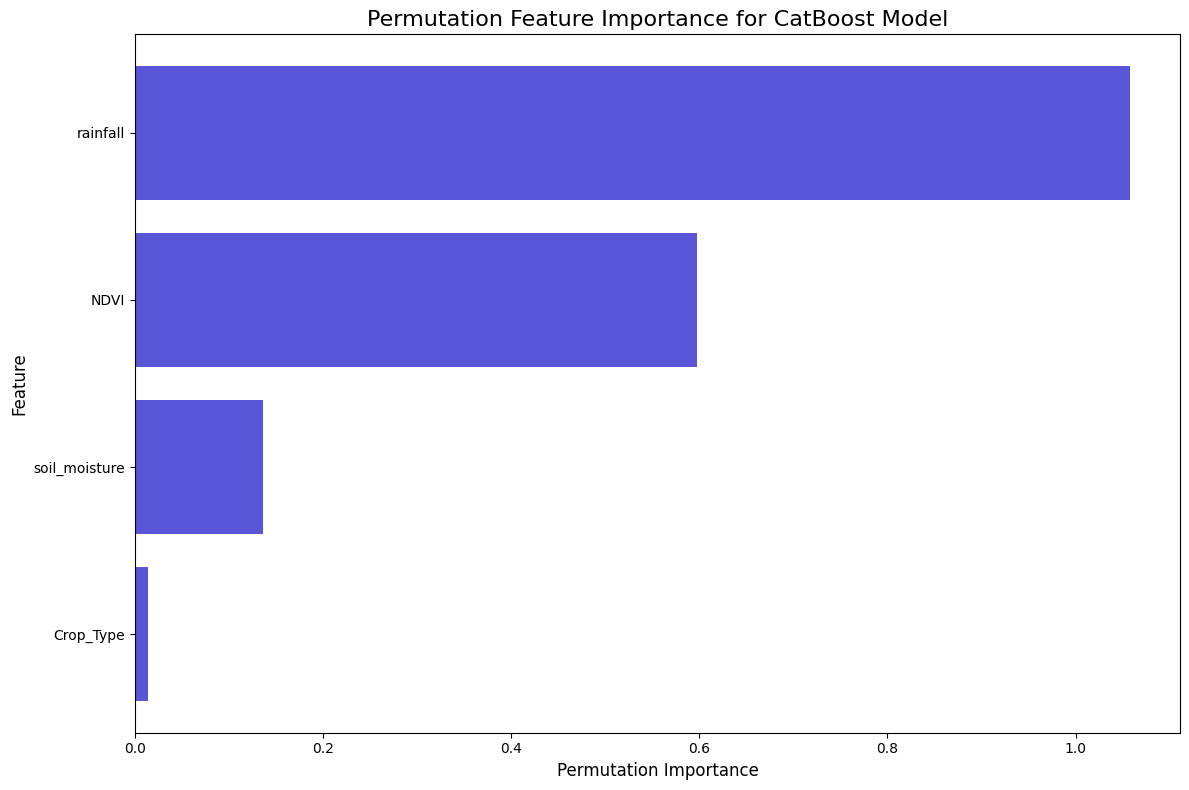

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# Calculate permutation importance
perm_importance = permutation_importance(
    final_cat_anti_overfit, # Our trained CatBoost model
    X_train_cat,            # Training features
    y_train,                # Training target
    n_repeats=10,           # Number of times to permute a feature
    random_state=42,        # For reproducibility
    n_jobs=-1               # Use all available CPU cores
)

# Extract mean and standard deviation of importances
feature_importances = pd.DataFrame({
    'feature': X_train_cat.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
})

# Sort features by importance mean in descending order
feature_importances = feature_importances.sort_values(by='importance_mean', ascending=False)

# Create the horizontal bar plot
plt.figure(figsize=(12, 8))
plt.barh(
    feature_importances['feature'],
    feature_importances['importance_mean'],
    color='#5856D6'
)

# Add labels and title
plt.xlabel('Permutation Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Permutation Feature Importance for CatBoost Model', fontsize=16)
plt.gca().invert_yaxis() # Display highest importance at the top
plt.tight_layout()
plt.show()

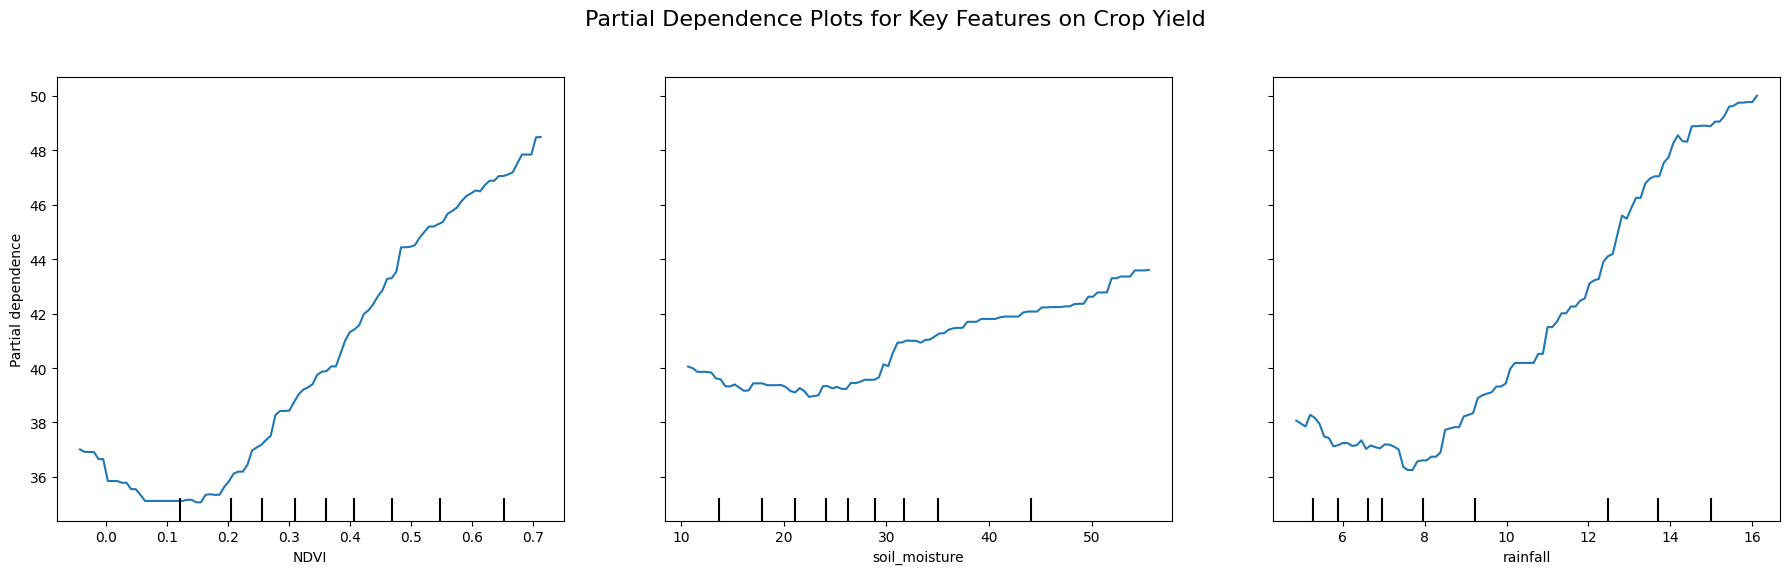

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Define the features for which to plot partial dependence
features_for_pdp = ['NDVI', 'soil_moisture', 'rainfall']

# Create a figure and axes for the plots
fig, ax = plt.subplots(figsize=(18, 6))

# Generate Partial Dependency Plots
# Note: CatBoost handles categorical features automatically, so we pass X_train_cat directly.
PartialDependenceDisplay.from_estimator(
    final_cat_anti_overfit, # Our trained CatBoost model
    X_train_cat,            # Training features (including 'Crop_Type' as a categorical feature)
    features_for_pdp,       # Features to plot
    kind='average',         # Plot the average partial dependence
    # grid_resolution=50,   # Number of points in grid to evaluate partial dependence
    ax=ax,
    feature_names=X_train_cat.columns.tolist() # Provide explicit feature names
    # plot_kw={'rug': False} # This argument caused a TypeError in this environment
)

# Add title and adjust layout
fig.suptitle('Partial Dependence Plots for Key Features on Crop Yield', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()